# Evaluation of the 25 baseline imputation methods, plus MOFA+

This notebook evaluates the 25 general-purpose / left-censored / R-backed /
deep-learning methods benchmarked in `benchmark_imputation_clinicalv1.ipynb`.

**MOFA+** is trained separately, in `evaluate_mofaplus_multiomic_clinicalv2.ipynb`.
But it is scored the same way. Same metrics, same masked entries. Its results
land in the checkpoint files the 25 methods already use. So they show up here
too — in every table and figure below, once that notebook has been run.

**MOFA-Flex** and **MOFA-Flex-GraphGP** are trained separately too, in
`evaluate_mofaflex_multiomic_clinical.ipynb` and
`evaluate_mofaflex_graphgp_multiomic_clinical.ipynb`. The same as MOFA+: both write
directly into the same `pilot_checkpoint.csv` / `benchmark_checkpoint_<matrix>.csv` this
notebook already reads, scored the same way, on the same masked entries - so their rows
show up in every table and figure below too, once those notebooks have been run.

### Metrics used, and why

- **MAE, RMSE** — standard, computed on every masked (withheld) entry
  pooled together, already produced by `calculate_metrics` in the benchmark.
- **NRMSE** — RMSE normalized by each feature's own observed value range,
  *then averaged across features* (Ma et al. 2020).
  This exists because RMSE/MAE pooled across features of very different
  baseline scale are dominated by whichever features happen to have the
  largest values — NRMSE corrects for that.

- **Pearson r** is reported two ways below: the *raw pooled* value already
  produced by `calculate_metrics` (pools every masked entry across every
  feature, with no adjustment), and a **feature-centered pooled** value
  (each feature's masked truth/prediction values are centered on their own
  mean *before* pooling, then one correlation is computed over the whole
  pooled set). Raw pooled correlation has the same between-feature-scale
  problem NRMSE was built to fix — with features at very different baseline
  abundances, a raw pooled correlation is inflated by the fact that both
  truth and prediction preserve *between-feature* separation, which is a
  much easier signal to reproduce than *within-feature* recovery quality.
  Feature-centering removes that confound while still pooling all masked
  entries into a single statistic.
- **Spearman r** is reported the same two ways, for the same reason.

In [43]:
# --- Cell 1: cap CPU thread usage, imports, and path resolution ---
import os
import warnings
from pathlib import Path


def _cluster_cpu_budget(default=4):
    """How many CPU threads/workers this job should actually use.
    """
    override = os.environ.get("IMPUTATION_CPU_BUDGET")
    if override:
        try:
            return max(1, int(override)), "IMPUTATION_CPU_BUDGET override"
        except ValueError:
            print(f"IMPUTATION_CPU_BUDGET={override!r} isn't a valid integer - ignoring it.")

    for var in ("SLURM_CPUS_PER_TASK", "SLURM_CPUS_ON_NODE"):
        val = os.environ.get(var)
        if val:
            try:
                return max(1, int(val)), var
            except ValueError:
                pass
    val = os.environ.get("SLURM_JOB_CPUS_PER_NODE")
    if val:
        import re
        m = re.match(r"(\d+)", val)
        if m:
            return max(1, int(m.group(1))), "SLURM_JOB_CPUS_PER_NODE"

    try:
        return max(1, len(os.sched_getaffinity(0))), "CPU affinity (no Slurm allocation, no override detected)"
    except AttributeError:
        return max(1, os.cpu_count() or default), "os.cpu_count() (no Slurm allocation, no override detected)"


# Must run before numpy/pandas/mudata/matplotlib are imported below - they
# read their thread count once, at import time, so this has to come first.
N_JOBS, _cpu_budget_source = _cluster_cpu_budget()
for _var in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
             "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_var] = str(N_JOBS)
print(f"CPU budget for this session: {N_JOBS} threads (source: {_cpu_budget_source})")
if _cpu_budget_source.startswith(("CPU affinity", "os.cpu_count")):
    print(
        "  no Slurm allocation detected - this looks like an unmanaged node. If sharing it "
        "with others, set IMPUTATION_CPU_BUDGET to a smaller number "
        "before starting this kernel, e.g. `export IMPUTATION_CPU_BUDGET=16`."
    )

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import mudata as mu
from scipy.stats import spearmanr

mu.set_options(pull_on_update=False)
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

RNG_SEED = 0  # must match benchmark_imputation_clinical.ipynb/py, so the pilot mask reproduces identically

try:
    THIS_DIR = Path(__file__).resolve().parent
except NameError:
    THIS_DIR = Path.cwd()

BASE_DIR = THIS_DIR.parent  # project root, e.g. /home/rnjue/Imputationv2

CANDIDATE_PROCESSED_DIRS = []
if os.environ.get("IMPUTATION_OUTPUT_DIR"):
    CANDIDATE_PROCESSED_DIRS.append(Path(os.environ["IMPUTATION_OUTPUT_DIR"]).expanduser())
CANDIDATE_PROCESSED_DIRS += [
    BASE_DIR / "data" / "processed",
    Path.home() / "reuben_imputation" / "processed",
    Path("/projects/datasets_BIO/reuben_imputation/processed"),
    THIS_DIR / "processed",
]
PROCESSED_DIR = next((d for d in CANDIDATE_PROCESSED_DIRS if d.exists()), None)
if PROCESSED_DIR is None:
    raise FileNotFoundError(
        "no 'processed' directory found among: " + ", ".join(str(d) for d in CANDIDATE_PROCESSED_DIRS) +
        ". Run read_multiomic_Data_clinical.ipynb through Cell 14 first, or set IMPUTATION_OUTPUT_DIR."
    )

CANDIDATE_RESULTS_DIRS = [
    BASE_DIR / "results",
    PROCESSED_DIR.parent / "imputation_results",
    Path.home() / "reuben_imputation" / "imputation_results",
]
RESULTS_DIR = next((d for d in CANDIDATE_RESULTS_DIRS if d.exists()), None)
if RESULTS_DIR is None:
    raise FileNotFoundError(
        "no imputation_results directory found among: " + ", ".join(str(d) for d in CANDIDATE_RESULTS_DIRS) +
        ". Run benchmark_imputation_clinical.ipynb first."
    )
PILOT_MATRICES_DIR = RESULTS_DIR / "pilot_imputed_matrices"
FIGURES_DIR = RESULTS_DIR / "evaluation_figures"
FIGURES_DIR.mkdir(exist_ok=True)
print("processed dir:", PROCESSED_DIR, "| results dir:", RESULTS_DIR)

mdata = mu.read_h5mu(PROCESSED_DIR / "dlbcl_mudata_filtered.h5mu")
crc_df = pd.read_csv(PROCESSED_DIR / "crc_proteomics_samples_x_features.csv", index_col=0)


def to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]

CPU budget for this session: 80 threads (source: CPU affinity (no Slurm allocation, no override detected))
  no Slurm allocation detected - this looks like an unmanaged node. If sharing it with others, set IMPUTATION_CPU_BUDGET to a smaller number before starting this kernel, e.g. `export IMPUTATION_CPU_BUDGET=16`.
processed dir: /home/rnjue/Imputationv2/data/processed | results dir: /home/rnjue/Imputationv2/results


In [44]:
# --- Cell 2: rebuild the three truth matrices ---
# Mirrors benchmark_imputation_clinical.ipynb/py's Cell 3 - needed both to reconstruct the
# pilot mask and to sanity-check the loaded matrices against truth. It has to stay exactly
# identical to that cell (same N_TOP_FEATURES, same feature-selection logic), or the pilot
# mask reconstructed below won't match the one actually used when the persisted matrices
# were produced.
rna_adata = mdata.mod["1_rna"]
assert (rna_adata.obs_names == mdata.obs_names).all()
profiled_mask = mdata.obs["rna_profiled"].to_numpy()

rna_full = pd.DataFrame(
    to_dense(rna_adata.X)[profiled_mask].T, index=rna_adata.var_names, columns=rna_adata.obs_names[profiled_mask]
)
prot_full = pd.DataFrame(to_dense(mdata.mod["2_prot"].X).T, index=mdata.mod["2_prot"].var_names, columns=mdata.obs_names)
crc_full = crc_df.T

N_TOP_FEATURES = 500  # keep this in sync with benchmark_imputation_clinical.ipynb/py


def top_variable_features(df, n):
    if df.shape[0] <= n:
        return df
    top_idx = df.var(axis=1, skipna=True).sort_values(ascending=False).index[:n]
    return df.loc[df.index.isin(top_idx)]


MATRICES = {
    "dlbcl_rna": top_variable_features(rna_full, N_TOP_FEATURES),
    "dlbcl_protein": top_variable_features(prot_full, N_TOP_FEATURES),
    "crc_protein": top_variable_features(crc_full, N_TOP_FEATURES),
}
PROTEIN_MATRICES = {"dlbcl_protein", "crc_protein"}
for name, df in MATRICES.items():
    print(f"{name}: {df.shape}")

dlbcl_rna: (500, 318)
dlbcl_protein: (500, 332)
crc_protein: (500, 997)


In [45]:
# --- Cell 3: masking functions ---
# Mirrors Cell 4 of the benchmark notebook. Needed only to regenerate the deterministic pilot
# mask - the same seed and the same PILOT_ROW reproduce the same mask; see Cell 15's
# docstring in the benchmark file for the details.
from scipy.stats import norm as _mnar_norm
from scipy.optimize import minimize as _mnar_minimize


def fit_mnar_probit_params(X, min_features=20):
    """Calibrate Phi(a + b*Y) from a matrix's own real (pre-masking)
    missingness. Y is a feature's own observed-mean log2 abundance, used as
    the abundance proxy since a missing cell's true value is unknown by
    definition. Falls back to (a=0, b=0) - an uninformative, MCAR-like
    weighting - when there isn't enough real missingness to fit from.
    """
    vals = X.values.astype(float)
    n_features, n_samples = vals.shape
    observed = np.isfinite(vals)
    missing = ~observed

    feat_mean = np.full(n_features, np.nan)
    has_obs = observed.any(axis=1)
    feat_mean[has_obs] = np.nanmean(np.where(observed, vals, np.nan)[has_obs], axis=1)

    usable_rows = has_obs
    n_usable = usable_rows.sum()
    n_with_any_missing = (missing[usable_rows].any(axis=1)).sum()

    diagnostics = {
        "n_features_total": n_features, "n_features_usable": int(n_usable),
        "n_features_with_missing": int(n_with_any_missing),
    }

    if n_usable < min_features or n_with_any_missing < 5:
        diagnostics["fit_status"] = "insufficient_data_fallback_to_mcar_like"
        return 0.0, 0.0, diagnostics

    x = np.repeat(feat_mean[usable_rows], n_samples)
    y = missing[usable_rows].ravel().astype(float)

    x_mean, x_std = x.mean(), x.std()
    if x_std == 0:
        diagnostics["fit_status"] = "zero_variance_abundance_fallback_to_mcar_like"
        return 0.0, 0.0, diagnostics
    xs = (x - x_mean) / x_std

    def neg_log_lik(params):
        a_s, b_s = params
        p = _mnar_norm.cdf(a_s + b_s * xs)
        eps = 1e-9
        p = np.clip(p, eps, 1 - eps)
        return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

    p0 = y.mean()
    a0 = _mnar_norm.ppf(np.clip(p0, 1e-3, 1 - 1e-3))
    res = _mnar_minimize(
        neg_log_lik, x0=[a0, 0.0], method="Nelder-Mead",
        options={"xatol": 1e-8, "fatol": 1e-10, "maxiter": 2000},
    )
    if not res.success:
        diagnostics["fit_status"] = f"optimizer_failed_fallback_to_mcar_like ({res.message})"
        return 0.0, 0.0, diagnostics

    a_s, b_s = res.x
    b = b_s / x_std
    a = a_s - b_s * x_mean / x_std

    pred_p = _mnar_norm.cdf(a + b * x)
    ll_fit = -neg_log_lik(res.x)
    if 0 < p0 < 1:
        ll_null = np.sum(y * np.log(p0) + (1 - y) * np.log(1 - p0))
        pseudo_r2 = float(1 - ll_fit / ll_null) if ll_null != 0 else float("nan")
    else:
        pseudo_r2 = float("nan")
    diagnostics.update({
        "fit_status": "ok", "a": float(a), "b": float(b),
        "empirical_missing_rate": float(y.mean()),
        "predicted_missing_rate": float(pred_p.mean()),
        "pseudo_r2_mcfadden": pseudo_r2,
    })
    return float(a), float(b), diagnostics


MNAR_PROBIT_PARAMS = {}
print("Calibrating MNAR detection-limit curve Phi(a + b*Y) per matrix, from each matrix's own real missingness:")
for name, df in MATRICES.items():
    a_fit, b_fit, diag = fit_mnar_probit_params(df)
    MNAR_PROBIT_PARAMS[name] = (a_fit, b_fit)
    if diag["fit_status"] == "ok":
        extra = (f"empirical missing rate={diag['empirical_missing_rate']:.3f}, "
                 f"predicted={diag['predicted_missing_rate']:.3f}, "
                 f"pseudo-R2={diag['pseudo_r2_mcfadden']:.3f}")
    else:
        extra = f"{diag['n_features_usable']} usable features, {diag['n_features_with_missing']} with missing"
    print(f"  {name}: a={a_fit:.4f} b={b_fit:.4f} | {diag['fit_status']} | {extra}")
print("\nNote: a negative b means lower-abundance values are more likely to be missing "
      "(the expected detection-limit direction). a=0, b=0 means that matrix fell back to an "
      "uninformative, MCAR-like weighting because it didn't have enough real missingness to "
      "calibrate from.")


def generate_mnar_weighted_positions(X, n_to_mask, a, b, rng=None, exclude_mask=None):
    if rng is None:
        rng = np.random.default_rng()
    eligible = X.notna().values
    if exclude_mask is not None:
        eligible = eligible & ~exclude_mask.values
    positions = np.argwhere(eligible)
    if n_to_mask == 0:
        return np.empty((0, 2), dtype=int)
    values = X.values[eligible]  # raw log2 abundance, this entry's own real value
    weights = _mnar_norm.cdf(a + b * values)
    total = weights.sum()
    if total <= 0 or not np.isfinite(total):
        weights = np.ones_like(weights)
        total = weights.sum()
    weights = weights / total
    selected = rng.choice(len(positions), size=n_to_mask, replace=False, p=weights)
    return positions[selected]


def generate_mixed_mask(X, masking_fraction=0.30, mnar_fraction=0.50, a=0.0, b=0.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    eligible = X.notna().values
    n_eligible = eligible.sum()
    total_to_mask = int(round(masking_fraction * n_eligible))
    n_mnar = int(round(total_to_mask * mnar_fraction))
    n_mcar = total_to_mask - n_mnar

    mnar_positions = generate_mnar_weighted_positions(X, n_mnar, a, b, rng=rng)
    mnar_excl = np.zeros(X.shape, dtype=bool)
    if len(mnar_positions) > 0:
        mnar_excl[mnar_positions[:, 0], mnar_positions[:, 1]] = True
    mnar_excl_df = pd.DataFrame(mnar_excl, index=X.index, columns=X.columns)

    mcar_positions = np.empty((0, 2), dtype=int)
    if n_mcar > 0:
        available = np.argwhere(eligible & ~mnar_excl_df.values)
        n_mcar_clamped = min(n_mcar, len(available))
        mcar_positions = available[rng.choice(len(available), size=n_mcar_clamped, replace=False)]

    mask = np.zeros(X.shape, dtype=bool)
    mechanism = np.full(X.shape, "", dtype=object)
    if len(mnar_positions) > 0:
        mask[mnar_positions[:, 0], mnar_positions[:, 1]] = True
        mechanism[mnar_positions[:, 0], mnar_positions[:, 1]] = "MNAR"
    if len(mcar_positions) > 0:
        mask[mcar_positions[:, 0], mcar_positions[:, 1]] = True
        mechanism[mcar_positions[:, 0], mcar_positions[:, 1]] = "MCAR"
    return (
        pd.DataFrame(mask, index=X.index, columns=X.columns),
        pd.DataFrame(mechanism, index=X.index, columns=X.columns),
    )


def build_masked_scenario(row, X_truth, a=0.0, b=0.0):
    rng = np.random.default_rng(int(row["Seed"]))
    mask, mechanism = generate_mixed_mask(
        X_truth, masking_fraction=float(row["Masking_Fraction"]), mnar_fraction=float(row["MNAR_Fraction"]),
        a=a, b=b, rng=rng,
    )
    return X_truth.mask(mask), mask, mechanism


PILOT_ROW = pd.Series({"Masking_Fraction": 0.30, "MNAR_Fraction": 0.0, "Replicate": 1, "Seed": RNG_SEED})


Calibrating MNAR detection-limit curve Phi(a + b*Y) per matrix, from each matrix's own real missingness:
  dlbcl_rna: a=0.0000 b=0.0000 | insufficient_data_fallback_to_mcar_like | 500 usable features, 0 with missing
  dlbcl_protein: a=5.9795 b=-0.4202 | ok | empirical missing rate=0.602, predicted=0.599, pseudo-R2=0.161
  crc_protein: a=5.1386 b=-0.6097 | ok | empirical missing rate=0.040, predicted=0.040, pseudo-R2=0.350

Note: a negative b means lower-abundance values are more likely to be missing (the expected detection-limit direction). a=0, b=0 means that matrix fell back to an uninformative, MCAR-like weighting because it didn't have enough real missingness to calibrate from.


In [46]:
# --- Cell 4: metrics ---
# Used only to sanity-check the persisted pilot matrices against the RMSE already recorded in
# the pilot checkpoint - not to recompute the full-grid metrics, which are read straight from
# checkpoint further down, unchanged.
def calculate_metrics(truth, prediction, mask):
    y_true_mat, y_pred_mat, mask_mat = truth.values, prediction.values, mask.values
    y_true, y_pred = y_true_mat[mask_mat], y_pred_mat[mask_mat]
    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[valid], y_pred[valid]

    errors = y_true - y_pred
    rmse = np.sqrt(np.mean(errors ** 2)) if len(errors) else np.nan
    mae = np.mean(np.abs(errors)) if len(errors) else np.nan
    pearson_r = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan

    nrmse_vals = []
    min_masked_per_feature = 5
    for i in range(y_true_mat.shape[0]):
        row_mask = mask_mat[i]
        if row_mask.sum() < min_masked_per_feature:
            continue
        yt, yp = y_true_mat[i, row_mask], y_pred_mat[i, row_mask]
        v = np.isfinite(yt) & np.isfinite(yp)
        yt, yp = yt[v], yp[v]
        if len(yt) < min_masked_per_feature:
            continue
        feat_range = np.nanmax(y_true_mat[i]) - np.nanmin(y_true_mat[i])
        if not np.isfinite(feat_range) or feat_range <= 0:
            continue
        row_rmse = np.sqrt(np.mean((yt - yp) ** 2))
        nrmse_vals.append(row_rmse / feat_range)

    return {
        "RMSE": rmse, "MAE": mae, "Pearson_r": pearson_r,
        "NRMSE": float(np.mean(nrmse_vals)) if nrmse_vals else np.nan,
        "N_Evaluated": len(y_true),
    }

In [47]:
# --- Cell 5: feature-centered pooled correlations ------
# min_masked_per_feature=5 is kept identical to the threshold calculate_metrics uses for
# NRMSE, for consistency - a feature only contributes to the pooled correlation once it has
# enough masked, valid entries for "this feature's own mean" to be a meaningful reference
# point.
def pooled_correlations(X_truth, X_hat, mask, min_masked_per_feature=5):
    yt_mat, yp_mat, mask_mat = X_truth.values, X_hat.values, mask.values
    raw_true, raw_pred, cen_true, cen_pred = [], [], [], []
    n_features_used = 0
    for i in range(yt_mat.shape[0]):
        row_mask = mask_mat[i]
        if row_mask.sum() < min_masked_per_feature:
            continue
        yt, yp = yt_mat[i, row_mask], yp_mat[i, row_mask]
        v = np.isfinite(yt) & np.isfinite(yp)
        yt, yp = yt[v], yp[v]
        if len(yt) < min_masked_per_feature:
            continue
        raw_true.append(yt)
        raw_pred.append(yp)
        cen_true.append(yt - yt.mean())  # each feature is centered on its own mean before pooling
        cen_pred.append(yp - yp.mean())
        n_features_used += 1

    if n_features_used == 0:
        return {"Pearson_r_raw_pooled": np.nan, "Spearman_r_raw_pooled": np.nan,
                "Pearson_r_feature_centered_pooled": np.nan, "Spearman_r_feature_centered_pooled": np.nan,
                "N_Features_Pooled": 0}

    raw_true, raw_pred = np.concatenate(raw_true), np.concatenate(raw_pred)
    cen_true, cen_pred = np.concatenate(cen_true), np.concatenate(cen_pred)

    def _pearson(a, b):
        return np.corrcoef(a, b)[0, 1] if len(a) > 1 and np.std(a) > 0 and np.std(b) > 0 else np.nan

    def _spearman(a, b):
        return spearmanr(a, b).correlation if len(a) > 1 and np.std(a) > 0 and np.std(b) > 0 else np.nan

    return {
        "Pearson_r_raw_pooled": _pearson(raw_true, raw_pred),
        "Spearman_r_raw_pooled": _spearman(raw_true, raw_pred),
        "Pearson_r_feature_centered_pooled": _pearson(cen_true, cen_pred),
        "Spearman_r_feature_centered_pooled": _spearman(cen_true, cen_pred),
        "N_Features_Pooled": n_features_used,
    }

In [48]:
# --- Cell 6: load the pilot checkpoint and persisted matrices, compute pooled ---
# correlations per (matrix, method), and sanity-check them against the checkpoint's own
# RMSE.
PILOT_CHECKPOINT_PATH = RESULTS_DIR / "pilot_checkpoint.csv"
if not PILOT_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"{PILOT_CHECKPOINT_PATH} not found - run benchmark_imputation_clinical.ipynb/py's Cell 15 (pilot) first."
    )
pilot_checkpoint = pd.read_csv(PILOT_CHECKPOINT_PATH)
print(f"pilot checkpoint: {len(pilot_checkpoint)} (matrix, method) rows")

pilot_pooled_rows = []
_skipped_no_matrix_file = []
for matrix_name, X_truth in MATRICES.items():
    Y_masked, mask, mechanism = build_masked_scenario(PILOT_ROW, X_truth)
    matrix_rows = pilot_checkpoint[pilot_checkpoint["Matrix"] == matrix_name]
    for _, ckpt_row in matrix_rows.iterrows():
        method_name = ckpt_row["Method"]
        matrix_path = PILOT_MATRICES_DIR / f"pilot_{matrix_name}_imputed_{method_name}.csv"
        if not matrix_path.exists():
            _skipped_no_matrix_file.append((matrix_name, method_name))
            continue
        X_hat = pd.read_csv(matrix_path, index_col=0)
        X_hat = X_hat.reindex(index=X_truth.index, columns=X_truth.columns)

        recomputed = calculate_metrics(X_truth, X_hat, mask)
        if np.isfinite(recomputed["RMSE"]) and np.isfinite(ckpt_row.get("RMSE", np.nan)):
            if not np.isclose(recomputed["RMSE"], ckpt_row["RMSE"], rtol=1e-4, atol=1e-6):
                print(f"  !! WARNING: {matrix_name}/{method_name} recomputed RMSE "
                      f"({recomputed['RMSE']:.4f}) differs from checkpoint RMSE "
                      f"({ckpt_row['RMSE']:.4f})")

        pooled = pooled_correlations(X_truth, X_hat, mask)
        pooled.update({"Matrix": matrix_name, "Method": method_name})
        pilot_pooled_rows.append(pooled)

_POOLED_CORR_COLS = ["Pearson_r_raw_pooled", "Spearman_r_raw_pooled",
                      "Pearson_r_feature_centered_pooled", "Spearman_r_feature_centered_pooled",
                      "N_Features_Pooled"]
if pilot_pooled_rows:
    pilot_pooled = pd.DataFrame(pilot_pooled_rows)
else:
    pilot_pooled = pd.DataFrame(columns=["Matrix", "Method"] + _POOLED_CORR_COLS)

if _skipped_no_matrix_file:
    print(f"\n{len(_skipped_no_matrix_file)} of {len(pilot_checkpoint)} (matrix, method) pairs have a "
          "checkpoint row but no saved matrix file - excluded from pooled-correlation results "
          "(RMSE/MAE from the checkpoint are unaffected).")
    if len(_skipped_no_matrix_file) == len(pilot_checkpoint):
        print("\n*** ALL pilot (matrix, method) pairs are missing their saved matrix file. "
              "pilot_pooled has zero rows but the correct columns - pooled-correlation columns "
              "in pilot_summary will be all-NaN, not missing. ***")

print(f"\npooled correlations computed for {len(pilot_pooled)} (matrix, method) pairs")

pilot checkpoint: 78 (matrix, method) rows



pooled correlations computed for 78 (matrix, method) pairs


In [49]:
# --- Cell 7: pilot-scenario summary table (merge checkpoint + pooled correlations) ------
# pilot_checkpoint can already carry the pooled-correlation columns itself - for MOFA+
# methods, evaluate_mofaplus_multiomic_clinical.ipynb's score_full() bundles
# pooled_correlations() straight into the rows it writes there. But pilot_pooled (built
# fresh in Cell 6, from the saved matrices, for every method) is the authoritative source
# for this notebook, so we drop any pre-existing copies from pilot_checkpoint before
# merging, otherwise pandas would silently suffix both copies (_x/_y) instead of raising
# an error, and the bare column name would never make it into pilot_summary at all.
_POOLED_COLS_TO_DROP = ["Cor_proteinwise"] + _POOLED_CORR_COLS
pilot_summary = pilot_checkpoint.drop(columns=_POOLED_COLS_TO_DROP, errors="ignore").merge(
    pilot_pooled, on=["Matrix", "Method"], how="left"
)
pilot_summary_cols = [
    "Matrix", "Method", "MAE", "RMSE", "NRMSE",
    "Pearson_r_raw_pooled", "Spearman_r_raw_pooled",
    "Pearson_r_feature_centered_pooled", "Spearman_r_feature_centered_pooled",
    "N_Evaluated", "N_Features_Pooled", "Seconds",
]
pilot_summary = pilot_summary[[c for c in pilot_summary_cols if c in pilot_summary.columns]]
pilot_summary = pilot_summary.sort_values(["Matrix", "RMSE"])

assert "Pearson_r_feature_centered_pooled" in pilot_summary.columns, (
    "pilot_summary is missing 'Pearson_r_feature_centered_pooled' right after being built. "
    "That should not be possible if Cell 6 ran in this same kernel session just before this cell - "
    "editing a cell's code does not retroactively fix a variable an earlier run already computed. "
    "Re-run Cell 6, then this cell, in that order."
)

pilot_summary.to_csv(RESULTS_DIR / "pilot_evaluation_summary.csv", index=False)
pilot_summary

,Matrix,Method,MAE,RMSE,NRMSE,Pearson_r_raw_pooled,Spearman_r_raw_pooled,Pearson_r_feature_centered_pooled,Spearman_r_feature_centered_pooled,N_Evaluated,N_Features_Pooled,Seconds
65,crc_protein,MOFA+_native,0.866768,1.309410,0.107261,0.910194,0.905948,5.196288e-01,0.536238,143543,500,15.458610
61,crc_protein,DreamAI,0.881487,1.322847,0.109120,0.908277,0.904055,5.053661e-01,0.523076,143543,500,7456.759324
56,crc_protein,DreamAI_MissForest,0.885619,1.325667,0.109819,0.907850,0.903816,5.046411e-01,0.528528,143543,500,585.653393
59,crc_protein,DreamAI_SpectroFM,0.920767,1.348239,0.113603,0.905234,0.901973,4.817609e-01,0.497598,143543,500,16.035346
43,crc_protein,MICE,0.906035,1.349374,0.111547,0.904348,0.900424,4.749610e-01,0.489839,143543,500,16.474751
...,...,...,...,...,...,...,...,...,...,...,...,...
3,dlbcl_rna,Regression,0.923507,1.393120,0.172515,0.740356,0.778144,5.961624e-01,0.626941,47700,500,6.339565
10,dlbcl_rna,VAE,1.114817,1.439523,0.197907,0.689611,0.684844,4.644118e-01,0.379178,47700,500,2.682951
0,dlbcl_rna,Mean,1.296919,1.618873,0.225852,0.578896,0.563446,8.114803e-09,-0.004502,47700,500,0.237043
1,dlbcl_rna,Median,1.257569,1.669856,0.232501,0.573435,0.560716,2.579763e-08,-0.003959,47700,500,0.157564


### MOFA+ vs. the best conventional method (pilot scenario)

Now we bring MOFA+ into the comparison. It was trained on its own, in a separate notebook. But it was scored the same way, on the same masked entries. So the numbers line up directly.

For each matrix, we take the best of the 25 conventional methods by RMSE. Then we check every MOFA+ variant against it. This table only fills in once `evaluate_mofaplus_multiomic_clinical.ipynb` has been run.

In [50]:
# --- MOFA+ vs. best conventional method (pilot scenario) -----
# pilot_summary already carries MOFA+'s rows if evaluate_mofaplus_multiomic_clinical.ipynb
# has been run - it writes into the same pilot_checkpoint.csv that this notebook reads in
# Cell 6.
MOFAPLUS_METHOD_NAMES = {"MOFA+_native", "MOFA+_after_QRILC", "MOFA+_after_MinProb", "MOFA+_joint"}
MOFAFLEX_METHOD_NAMES = {"MOFA-Flex", "MOFA-Flex-GraphGP"}
# Every factor-model method, MOFA+ and MOFA-Flex alike - used below to keep the
# "best conventional" baseline honest: once MOFA-Flex rows exist in this same
# checkpoint, only excluding MOFA+ by name would let MOFA-Flex get counted as
# "conventional" when comparing MOFA+ against it (and vice versa).
FACTOR_MODEL_METHOD_NAMES = MOFAPLUS_METHOD_NAMES | MOFAFLEX_METHOD_NAMES

mofaplus_pilot_rows = pilot_summary[pilot_summary["Method"].isin(MOFAPLUS_METHOD_NAMES)]
if mofaplus_pilot_rows.empty:
    print("No MOFA+ rows yet -- run evaluate_mofaplus_multiomic_clinical.ipynb first.")
    mofaplus_vs_best_pilot = pd.DataFrame()
else:
    comparison_rows = []
    for matrix_name in MATRICES:
        conv = pilot_summary[
            (pilot_summary["Matrix"] == matrix_name) & (~pilot_summary["Method"].isin(FACTOR_MODEL_METHOD_NAMES))
        ].dropna(subset=["RMSE"])
        mofa_here = mofaplus_pilot_rows[mofaplus_pilot_rows["Matrix"] == matrix_name].dropna(subset=["RMSE"])
        if conv.empty or mofa_here.empty:
            continue
        best_conv = conv.loc[conv["RMSE"].idxmin()]
        for _, row in mofa_here.iterrows():
            comparison_rows.append({
                "Matrix": matrix_name,
                "MOFA+ variant": row["Method"],
                "MOFA+ RMSE": row["RMSE"],
                "Best conventional method": best_conv["Method"],
                "Best conventional RMSE": best_conv["RMSE"],
                "MOFA+ wins": bool(row["RMSE"] < best_conv["RMSE"]),
            })
    mofaplus_vs_best_pilot = pd.DataFrame(comparison_rows)
    mofaplus_vs_best_pilot.to_csv(RESULTS_DIR / "mofaplus_vs_best_conventional_pilot.csv", index=False)
mofaplus_vs_best_pilot

,Matrix,MOFA+ variant,MOFA+ RMSE,Best conventional method,Best conventional RMSE,MOFA+ wins
0,dlbcl_rna,MOFA+_native,1.182306,MICE,1.235383,True
1,dlbcl_rna,MOFA+_joint,1.209103,MICE,1.235383,True
2,dlbcl_protein,MOFA+_native,0.513483,DreamAI,0.512071,False
3,dlbcl_protein,MOFA+_joint,0.538706,DreamAI,0.512071,False
4,dlbcl_protein,MOFA+_after_QRILC,1.073532,DreamAI,0.512071,False
5,dlbcl_protein,MOFA+_after_MinProb,1.704394,DreamAI,0.512071,False
6,crc_protein,MOFA+_native,1.309410,DreamAI,1.322847,True
7,crc_protein,MOFA+_after_MinProb,3.007812,DreamAI,1.322847,False
8,crc_protein,MOFA+_after_QRILC,3.882056,DreamAI,1.322847,False


### MOFA-Flex and MOFA-Flex-GraphGP vs. the best conventional method (pilot scenario)

Same comparison, extended to the two MOFA-Flex variants. Both train via Pyro-backed
stochastic variational inference rather than MOFA+'s closed-form coordinate-ascent -
`factor_prior="Normal"`, `weight_prior="SpikeSlab"` for MOFA-Flex, or a `GraphGP` weight
prior built from the STRING PPI network's Laplacian eigenbasis for MOFA-Flex-GraphGP (see
`evaluate_mofaflex_multiomic_clinical.ipynb` / `evaluate_mofaflex_graphgp_multiomic_clinical.ipynb`
for the full model description). Both write into the same `pilot_checkpoint.csv` MOFA+ and
the 25 conventional methods already use, so their numbers line up directly here too.

The "best conventional" baseline below excludes every factor-model method - MOFA+
variants included, not just the two MOFA-Flex ones - for the same reason noted above.

In [51]:
# --- MOFA-Flex / MOFA-Flex-GraphGP vs. best conventional method (pilot scenario) ------
# Mirrors the MOFA+ comparison above, for the two MOFA-Flex variants. Both write into the
# same pilot_checkpoint.csv (see evaluate_mofaflex_multiomic_clinical.ipynb's Cell 6 and
# evaluate_mofaflex_graphgp_multiomic_clinical.ipynb's Cell 7).
mofaflex_pilot_rows = pilot_summary[pilot_summary["Method"].isin(MOFAFLEX_METHOD_NAMES)]
if mofaflex_pilot_rows.empty:
    print("No MOFA-Flex rows yet - run evaluate_mofaflex_multiomic_clinical.ipynb and/or "
          "evaluate_mofaflex_graphgp_multiomic_clinical.ipynb first.")
    mofaflex_vs_best_pilot = pd.DataFrame()
else:
    comparison_rows = []
    for matrix_name in MATRICES:
        conv = pilot_summary[
            (pilot_summary["Matrix"] == matrix_name) & (~pilot_summary["Method"].isin(FACTOR_MODEL_METHOD_NAMES))
        ].dropna(subset=["RMSE"])
        mofaflex_here = mofaflex_pilot_rows[mofaflex_pilot_rows["Matrix"] == matrix_name].dropna(subset=["RMSE"])
        if conv.empty or mofaflex_here.empty:
            continue
        best_conv = conv.loc[conv["RMSE"].idxmin()]
        for _, row in mofaflex_here.iterrows():
            comparison_rows.append({
                "Matrix": matrix_name,
                "MOFA-Flex variant": row["Method"],
                "MOFA-Flex RMSE": row["RMSE"],
                "Best conventional method": best_conv["Method"],
                "Best conventional RMSE": best_conv["RMSE"],
                "MOFA-Flex wins": bool(row["RMSE"] < best_conv["RMSE"]),
            })
    mofaflex_vs_best_pilot = pd.DataFrame(comparison_rows)
    mofaflex_vs_best_pilot.to_csv(RESULTS_DIR / "mofaflex_vs_best_conventional_pilot.csv", index=False)
mofaflex_vs_best_pilot

,Matrix,MOFA-Flex variant,MOFA-Flex RMSE,Best conventional method,Best conventional RMSE,MOFA-Flex wins
0,dlbcl_rna,MOFA-Flex-GraphGP,1.260055,MICE,1.235383,False
1,dlbcl_rna,MOFA-Flex,1.266822,MICE,1.235383,False
2,dlbcl_protein,MOFA-Flex-GraphGP,0.544337,DreamAI,0.512071,False
3,dlbcl_protein,MOFA-Flex,0.552243,DreamAI,0.512071,False
4,crc_protein,MOFA-Flex-GraphGP,1.361076,DreamAI,1.322847,False
5,crc_protein,MOFA-Flex,1.361101,DreamAI,1.322847,False


In [52]:
# --- Cell 8: load the full factorial grid ---
# must run benchmark_imputation_clinical.ipynb/py's Cell 16 execution loop before this cell 
# if you want the full-grid figures below; otherwise this notebook falls back gracefully to
# pilot-scenario-only results, with a clear message, rather than failing outright.
full_grid_frames = {}
for matrix_name in MATRICES:
    ckpt_path = RESULTS_DIR / f"benchmark_checkpoint_{matrix_name}.csv"
    if ckpt_path.exists():
        full_grid_frames[matrix_name] = pd.read_csv(ckpt_path).assign(Matrix=matrix_name)
    else:
        print(f"  (no full-grid checkpoint for {matrix_name} yet: {ckpt_path})")

HAVE_FULL_GRID = len(full_grid_frames) > 0
if HAVE_FULL_GRID:
    all_results = pd.concat(full_grid_frames.values(), ignore_index=True)
    all_results = all_results.drop(columns=["Cor_proteinwise"], errors="ignore")
    all_results.to_csv(RESULTS_DIR / "benchmark_results_full.csv", index=False)
    print(f"loaded full-grid results: {all_results.shape}, matrices: {sorted(full_grid_frames)}")
else:
    all_results = pd.DataFrame()
    print(
        "\nNo full-grid checkpoints found for any matrix. In benchmark_imputation_clinical.ipynb/py, run Cell 16's "
        "execution loop:\n"
        "  results = {}\n"
        "  for matrix_name, X in MATRICES.items():\n"
        "      results[matrix_name] = run_full_benchmark(matrix_name, X, RESULTS_DIR / "
        "f'benchmark_checkpoint_{matrix_name}.csv')\n"
        ", then re-run this notebook from Cell 8 onward. Everything below Cell 8 that depends on "
        "the full grid will be skipped for now; the pilot-scenario summary above (Cell 7) still stands on "
        "its own."
    )

loaded full-grid results: (1875, 16), matrices: ['crc_protein', 'dlbcl_protein', 'dlbcl_rna']


In [53]:
# --- Cell 9: full-grid aggregate ranking (mean/std/count per Matrix x Method) ---
if HAVE_FULL_GRID:
    full_grid_agg = (
        all_results.groupby(["Matrix", "Method"])[["RMSE", "MAE", "NRMSE", "Pearson_r"]]
        .agg(["mean", "std", "count"])
    )
    full_grid_agg.columns = ["_".join(c) for c in full_grid_agg.columns]
    full_grid_agg = full_grid_agg.sort_values(["Matrix", "RMSE_mean"]).reset_index()
    full_grid_agg.to_csv(RESULTS_DIR / "benchmark_results_aggregated.csv", index=False)
else:
    full_grid_agg = pd.DataFrame()
full_grid_agg

,Matrix,Method,RMSE_mean,RMSE_std,RMSE_count,MAE_mean,MAE_std,MAE_count,NRMSE_mean,NRMSE_std,NRMSE_count,Pearson_r_mean,Pearson_r_std,Pearson_r_count
0,crc_protein,DreamAI,1.803478,0.328332,20,1.143834,0.223740,20,0.121811,0.008948,20,0.860287,0.043176,20
1,crc_protein,ADMIN,1.880983,0.356176,20,1.189720,0.241164,20,0.123010,0.007910,20,0.836786,0.062422,20
2,crc_protein,MOFA+_native,1.930483,0.402495,25,1.268478,0.339936,25,0.131634,0.023696,25,0.755086,0.219195,25
3,crc_protein,DAE,1.930869,0.372730,25,1.278519,0.304071,25,0.136299,0.022049,25,0.754438,0.212793,25
4,crc_protein,MICE,1.933868,0.374499,25,1.277927,0.311810,25,0.134984,0.023027,25,0.756867,0.210055,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,dlbcl_rna,Regression,1.343301,0.038193,25,0.923343,0.005177,25,0.171384,0.001701,25,0.756255,0.011485,25
71,dlbcl_rna,VAE,1.457232,0.008956,25,1.125733,0.005419,25,0.200552,0.001163,25,0.681840,0.004769,25
72,dlbcl_rna,Mean,1.623650,0.003565,25,1.301558,0.002964,25,0.226683,0.000497,25,0.577817,0.002664,25
73,dlbcl_rna,Median,1.676683,0.004959,25,1.263707,0.004101,25,0.233546,0.000677,25,0.571807,0.002679,25


### MOFA+_native vs. the best conventional method (full grid)

Same comparison, now at full-grid scale. Only `MOFA+_native` runs the full grid — the pre-impute and joint variants stay pilot-only, by design. This table fills in once that notebook's Cell 11 has been run.

In [54]:
# --- MOFA+_native vs. best conventional method (full grid) ------
# for each matrix, restrict every conventional method to the EXACT same Scenario_ID
# set MOFA+_native was scored on, and only let a conventional method compete for
# "best" if it has a result for every one of those scenarios - partial coverage would let
# a method's mean be driven by however easy/hard the few scenarios it happened to have are,
# not by it actually being a stronger method.
if not HAVE_FULL_GRID:
    print("No full-grid checkpoints loaded yet - nothing to compare.")
    mofaplus_vs_best_full_grid = pd.DataFrame()
else:
    full_grid_mofa = full_grid_agg[full_grid_agg["Method"] == "MOFA+_native"]
    if full_grid_mofa.empty:
        print("No MOFA+_native rows in the full grid yet - run that notebook's Cell 11 first.")
        mofaplus_vs_best_full_grid = pd.DataFrame()
    else:
        rows = []
        for matrix_name in MATRICES:
            mofa_scenarios = set(
                all_results.loc[
                    (all_results["Matrix"] == matrix_name) & (all_results["Method"] == "MOFA+_native"),
                    "Scenario_ID",
                ]
            )
            mofa_row = full_grid_mofa[full_grid_mofa["Matrix"] == matrix_name]
            conv_all = full_grid_agg[
                (full_grid_agg["Matrix"] == matrix_name) & (~full_grid_agg["Method"].isin(FACTOR_MODEL_METHOD_NAMES))
            ]
            if not mofa_scenarios or mofa_row.empty or conv_all.empty:
                continue
            mofa_row = mofa_row.iloc[0]
            n_mofa_scenarios = len(mofa_scenarios)

            matched = all_results[
                (all_results["Matrix"] == matrix_name)
                & (all_results["Scenario_ID"].isin(mofa_scenarios))
                & (~all_results["Method"].isin(FACTOR_MODEL_METHOD_NAMES))
            ]
            matched_agg = matched.groupby("Method")["RMSE"].agg(["mean", "count"]).rename(
                columns={"mean": "RMSE_mean_matched", "count": "N_matched"}
            )
            fully_covered = matched_agg[matched_agg["N_matched"] == n_mofa_scenarios]
            if fully_covered.empty:
                best_conv_matched_name, best_conv_matched_rmse, n_conv_fully_covered = None, np.nan, 0
            else:
                best_conv_matched_name = fully_covered["RMSE_mean_matched"].idxmin()
                best_conv_matched_rmse = fully_covered.loc[best_conv_matched_name, "RMSE_mean_matched"]
                n_conv_fully_covered = len(fully_covered)

            best_conv_full = conv_all.loc[conv_all["RMSE_mean"].idxmin()]

            rows.append({
                "Matrix": matrix_name,
                "MOFA+_native mean RMSE": mofa_row["RMSE_mean"],
                "N scenarios (MOFA+_native)": n_mofa_scenarios,
                "Best conventional method (scenario-matched)": best_conv_matched_name,
                "Best conventional mean RMSE (scenario-matched)": best_conv_matched_rmse,
                "N conventional methods fully covering those scenarios": n_conv_fully_covered,
                "MOFA+ wins (scenario-matched)": (
                    bool(mofa_row["RMSE_mean"] < best_conv_matched_rmse)
                    if pd.notna(best_conv_matched_rmse) else None
                ),
                "Best conventional method (full grid, all masking fractions)": best_conv_full["Method"],
                "Best conventional mean RMSE (full grid, all masking fractions)": best_conv_full["RMSE_mean"],
                "MOFA+ wins (full grid, all masking fractions)": bool(
                    mofa_row["RMSE_mean"] < best_conv_full["RMSE_mean"]
                ),
            })
        mofaplus_vs_best_full_grid = pd.DataFrame(rows)
        mofaplus_vs_best_full_grid.to_csv(RESULTS_DIR / "mofaplus_vs_best_conventional_full_grid.csv", index=False)
mofaplus_vs_best_full_grid


,Matrix,MOFA+_native mean RMSE,N scenarios (MOFA+_native),Best conventional method (scenario-matched),Best conventional mean RMSE (scenario-matched),N conventional methods fully covering those scenarios,MOFA+ wins (scenario-matched),"Best conventional method (full grid, all masking fractions)","Best conventional mean RMSE (full grid, all masking fractions)","MOFA+ wins (full grid, all masking fractions)"
0,dlbcl_rna,1.182344,25,MsImpute,1.171740,16,False,MsImpute,1.171740,False
1,dlbcl_protein,0.516534,25,MsImpute,0.498436,25,False,MsImpute,0.498436,False
2,crc_protein,1.930483,25,DAE,1.930869,23,True,DreamAI,1.803478,False


### MOFA-Flex and MOFA-Flex-GraphGP vs. the best conventional method (full grid)

Unlike MOFA+ (where only `MOFA+_native` runs the full grid - the pre-impute and joint
variants stay pilot-only, by design), both MOFA-Flex variants ran with their own
`..._FULL_GRID_ALL_REPLICATES=True` across all three matrices, so each has genuine
full-grid coverage to stand on - not just a scenario-matched subset. The comparison below
is still run scenario-matched against the fully-covered conventional methods, the same way
as the MOFA+_native table above, for consistency; a "N scenarios" count well short of 25
for either variant on a given matrix is the signal that its full-grid run there is
genuinely incomplete (check `benchmark_checkpoint_<matrix>.csv`'s `Error` column). 

In [55]:
# --- MOFA-Flex / MOFA-Flex-GraphGP vs. best conventional method (full grid) ---
# Same scenario-matched-vs-best-conventional logic as the MOFA+_native comparison above,
# generalized to loop over both MOFA-Flex variants into one combined table (an added
# "Factor-model method" column identifies which). Both excluded from each other's and
# MOFA+'s "best conventional" baseline, same reasoning as the pilot comparison above.
if not HAVE_FULL_GRID:
    print("No full-grid checkpoints loaded yet - nothing to compare.")
    mofaflex_vs_best_full_grid = pd.DataFrame()
else:
    rows = []
    for mofaflex_method in sorted(MOFAFLEX_METHOD_NAMES):
        full_grid_this = full_grid_agg[full_grid_agg["Method"] == mofaflex_method]
        if full_grid_this.empty:
            continue
        for matrix_name in MATRICES:
            this_scenarios = set(
                all_results.loc[
                    (all_results["Matrix"] == matrix_name) & (all_results["Method"] == mofaflex_method),
                    "Scenario_ID",
                ]
            )
            this_row = full_grid_this[full_grid_this["Matrix"] == matrix_name]
            conv_all = full_grid_agg[
                (full_grid_agg["Matrix"] == matrix_name) & (~full_grid_agg["Method"].isin(FACTOR_MODEL_METHOD_NAMES))
            ]
            if not this_scenarios or this_row.empty or conv_all.empty:
                continue
            this_row = this_row.iloc[0]
            n_this_scenarios = len(this_scenarios)

            matched = all_results[
                (all_results["Matrix"] == matrix_name)
                & (all_results["Scenario_ID"].isin(this_scenarios))
                & (~all_results["Method"].isin(FACTOR_MODEL_METHOD_NAMES))
            ]
            matched_agg = matched.groupby("Method")["RMSE"].agg(["mean", "count"]).rename(
                columns={"mean": "RMSE_mean_matched", "count": "N_matched"}
            )
            fully_covered = matched_agg[matched_agg["N_matched"] == n_this_scenarios]
            if fully_covered.empty:
                best_conv_matched_name, best_conv_matched_rmse, n_conv_fully_covered = None, np.nan, 0
            else:
                best_conv_matched_name = fully_covered["RMSE_mean_matched"].idxmin()
                best_conv_matched_rmse = fully_covered.loc[best_conv_matched_name, "RMSE_mean_matched"]
                n_conv_fully_covered = len(fully_covered)

            best_conv_full = conv_all.loc[conv_all["RMSE_mean"].idxmin()]

            rows.append({
                "Matrix": matrix_name,
                "Factor-model method": mofaflex_method,
                "Mean RMSE": this_row["RMSE_mean"],
                "N scenarios": n_this_scenarios,
                "Best conventional method (scenario-matched)": best_conv_matched_name,
                "Best conventional mean RMSE (scenario-matched)": best_conv_matched_rmse,
                "N conventional methods fully covering those scenarios": n_conv_fully_covered,
                "Wins (scenario-matched)": (
                    bool(this_row["RMSE_mean"] < best_conv_matched_rmse)
                    if pd.notna(best_conv_matched_rmse) else None
                ),
                "Best conventional method (full grid, all masking fractions)": best_conv_full["Method"],
                "Best conventional mean RMSE (full grid, all masking fractions)": best_conv_full["RMSE_mean"],
                "Wins (full grid, all masking fractions)": bool(
                    this_row["RMSE_mean"] < best_conv_full["RMSE_mean"]
                ),
            })
    mofaflex_vs_best_full_grid = pd.DataFrame(rows)
    if not mofaflex_vs_best_full_grid.empty:
        mofaflex_vs_best_full_grid.to_csv(RESULTS_DIR / "mofaflex_vs_best_conventional_full_grid.csv", index=False)
    else:
        print("No MOFA-Flex full-grid rows yet - run the full-grid cell in "
              "evaluate_mofaflex_multiomic_clinical.ipynb and/or "
              "evaluate_mofaflex_graphgp_multiomic_clinical.ipynb first.")
mofaflex_vs_best_full_grid

,Matrix,Factor-model method,Mean RMSE,N scenarios,Best conventional method (scenario-matched),Best conventional mean RMSE (scenario-matched),N conventional methods fully covering those scenarios,Wins (scenario-matched),"Best conventional method (full grid, all masking fractions)","Best conventional mean RMSE (full grid, all masking fractions)","Wins (full grid, all masking fractions)"
0,dlbcl_rna,MOFA-Flex,1.271351,25,MsImpute,1.171740,16,False,MsImpute,1.171740,False
1,dlbcl_protein,MOFA-Flex,0.542089,25,MsImpute,0.498436,25,False,MsImpute,0.498436,False
2,crc_protein,MOFA-Flex,1.978354,25,DAE,1.930869,23,False,DreamAI,1.803478,False
3,dlbcl_rna,MOFA-Flex-GraphGP,1.265692,25,MsImpute,1.171740,16,False,MsImpute,1.171740,False
4,dlbcl_protein,MOFA-Flex-GraphGP,0.538624,25,MsImpute,0.498436,25,False,MsImpute,0.498436,False
5,crc_protein,MOFA-Flex-GraphGP,1.972493,25,DAE,1.930869,23,False,DreamAI,1.803478,False


In [64]:
# --- Cell 10: method-family grouping (for consistent coloring across the boxplots below) -----
# 25 individual methods can't each get a distinguishable color, but the 4 families can,
# using the same palette validated earlier in this project.
GENERAL_NAMES = {"Mean", "Median", "KNN", "SVD", "SoftImpute", "PPCA", "Regression", "RandomForest",
                  "MissForest", "MICE", "CF", "MsImpute", "EM_MVN", "LLS"}
LEFT_CENSORED_NAMES = {"MinDet", "MinProb", "QRILC", "LOD", "Zero", "HalfMin"}
R_BACKED_NAMES = {"BPCA", "DreamAI", "ADMIN"}
DEEP_LEARNING_NAMES = {"DAE", "VAE"}

MOFAPLUS_NAMES = {"MOFA+_native", "MOFA+_after_QRILC", "MOFA+_after_MinProb", "MOFA+_joint"}
MOFAFLEX_NAMES = {"MOFA-Flex", "MOFA-Flex-GraphGP"}
# Forced into Figs 3/4/6 below even when off their natural top-N/top-5/top-6 cut --- same
# treatment MOFA+ already got, extended to MOFA-Flex.
SPECIAL_METHOD_NAMES = MOFAPLUS_NAMES | MOFAFLEX_NAMES
FAMILY_COLOR = {
    "General-purpose": PALETTE[0], "MNAR/left-censored": PALETTE[1],
    "R-backed": PALETTE[2], "Deep learning": PALETTE[3],
    "MOFA+": "#999999",
    "MOFA-Flex": "#7d3c98",
    "Other": "#999999",  # defensive fallback for any method name not covered above (a typo, or a method added later)
}

def method_family(name):
    if name in GENERAL_NAMES:
        return "General-purpose"
    if name in LEFT_CENSORED_NAMES:
        return "MNAR/left-censored"
    if name in R_BACKED_NAMES:
        return "R-backed"
    if name in DEEP_LEARNING_NAMES:
        return "Deep learning"
    if name in MOFAPLUS_NAMES:
        return "MOFA+"
    if name in MOFAFLEX_NAMES:
        return "MOFA-Flex"
    return "Other"

def _boxplot_by_method(ax, df, value_col, matrix_name, title):
    sub = df[df["Matrix"] == matrix_name].dropna(subset=[value_col])
    if sub.empty:
        ax.set_visible(False)
        return
    # Coverage-aware, same reasoning as the top-N selection used in Figs 3/4 below: a
    # method whose full-grid run crashed or is still partial only has RMSE/NRMSE values
    # for whichever scenarios happened to finish. If those are disproportionately the
    # easier ones, its box would sit next to a fully-covered method's box as if the two
    # were computed on the same task, when they weren't. Excluded here rather than left
    # to the printed warning alone, since a boxplot has no room for a footnote.
    covered, under_covered = _fully_covered_methods(
        df[df["Matrix"] == matrix_name] if "Matrix" in df.columns else df, matrix_name
    )
    if under_covered:
        print(f"  {matrix_name}/{value_col}: excluding {len(under_covered)} under-covered method(s) from "
              f"this boxplot (partial/incomplete run - not directly comparable to a fully-covered "
              f"method's average): " +
              ", ".join(f"{m} ({n}/{exp})" for m, n, exp in sorted(under_covered)))
    sub = sub[sub["Method"].isin(covered)]
    if sub.empty:
        ax.set_visible(False)
        return
    order = sub.groupby("Method")[value_col].median().sort_values().index.tolist()
    data = [sub.loc[sub["Method"] == m, value_col].values for m in order]
    # Per-method N shown in the tick label - the count of non-null value_col rows actually
    # feeding that method's box, not a fixed/expected count. RMSE and NRMSE can have different
    # N for the same method (e.g. a feature-level NRMSE NaN that RMSE doesn't have), so this is
    # computed separately for Fig 1 vs Fig 2 rather than shared.
    counts = sub.groupby("Method")[value_col].count()
    labels = [f"{m} (n={counts[m]})" for m in order]
    colors = [FAMILY_COLOR[method_family(m)] for m in order]
    bp = ax.boxplot(data, vert=False, patch_artist=True, widths=0.6, showfliers=False,
                     medianprops=dict(color="black", linewidth=1.5))
    ax.set_yticks(range(1, len(order) + 1))
    ax.set_yticklabels(labels)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)
    ax.set_title(f"{matrix_name} -- {title}")
    ax.set_xlabel(value_col)
    ax.tick_params(axis="y", labelsize=8)

# --- Full-grid coverage awareness (mirrors benchmark_imputation_clinical.py's Cell 14
# FAST/MEDIUM/SLOW tiers and current single-masking-fraction/5-MNAR-value/5-replicate
# design, since the two notebooks don't share code directly; keep this in sync by hand
# if that grid or tiering ever changes shape again). Fig 3 and Fig 4 below both rank
# methods by median RMSE to pick a "top N" to plot, without a coverage check, a method
# that's only partway through its run (or crashed on most of its scenarios) can win that
# ranking purely because the few scenarios it does have happen to be easy, edging out a
# fully-covered method that's honestly averaged over its whole grid, including the hard
# scenarios. This mirrors the same logic applied to the MOFA+_native-vs-best-
# conventional-method comparison above, extended to these figures' method selection.
FAST_NAMES = {"Mean", "Median", "MinDet", "MinProb", "KNN", "SVD", "SoftImpute", "Zero",
              "HalfMin", "LOD", "QRILC", "LLS", "BPCA"}
MEDIUM_NAMES = {"PPCA", "Regression", "MICE", "CF", "MsImpute"}
SLOW_NAMES = {"RandomForest", "MissForest", "EM_MVN", "DreamAI", "ADMIN", "DAE", "VAE"}
N_REPLICATES = 5      # must match benchmark_imputation_clinical.py's experiment design
N_MNAR_VALUES = 5     # len(MNAR_FRACTIONS) there
N_MASKING_VALUES = 1  # len(MASKING_FRACTIONS) there

def _expected_n(method_name):
    """Full-grid scenario count a method is SUPPOSED to have per matrix under the current
    tiering. Returns None for a method this isn't defined for (any MOFA+ variant other
    than MOFA+_native, or an unrecognized name) - None means "no opinion," not "fine":
    such a method is never excluded by the coverage filter below, since there's nothing to
    compare its count against."""
    if method_name in FAST_NAMES:
        return N_REPLICATES * N_MNAR_VALUES * N_MASKING_VALUES
    if method_name in MEDIUM_NAMES or method_name in SLOW_NAMES or method_name == "MOFA+_native":
        return N_MNAR_VALUES * N_MASKING_VALUES
    if method_name in MOFAFLEX_NAMES:
        # Both MOFA-Flex variants' full-grid cells set their own *_FULL_GRID_ALL_REPLICATES
        # flag to True (evaluate_mofaflex_multiomic_clinical.ipynb's Cell 7,
        # evaluate_mofaflex_graphgp_multiomic_clinical.ipynb's Cell 8) - unlike
        # MOFA+_native, which only ever gets Replicate == 1, both run every replicate, so
        # their expected full-grid count is the full 25/matrix, same formula as FAST_NAMES.
        return N_REPLICATES * N_MNAR_VALUES * N_MASKING_VALUES
    return None

def _fully_covered_methods(df, matrix_name):
    """Returns (covered, under_covered) for one matrix's subset of all_results: `covered`
    is the set of method names whose actual RMSE-scenario count meets or exceeds their
    expected full-grid count (or that have no defined expectation, e.g. a pilot-only MOFA+
    variant); `under_covered` is a list of (method, actual_n, expected_n) for methods that
    fall short - a genuinely incomplete run, not a smaller-by-design tier."""
    sub = df[df["Matrix"] == matrix_name] if "Matrix" in df.columns else df
    counts = sub.groupby("Method")["RMSE"].count()
    covered, under_covered = set(), []
    for method, n in counts.items():
        expected = _expected_n(method)
        if expected is None or n >= expected:
            covered.add(method)
        else:
            under_covered.append((method, int(n), expected))
    return covered, under_covered

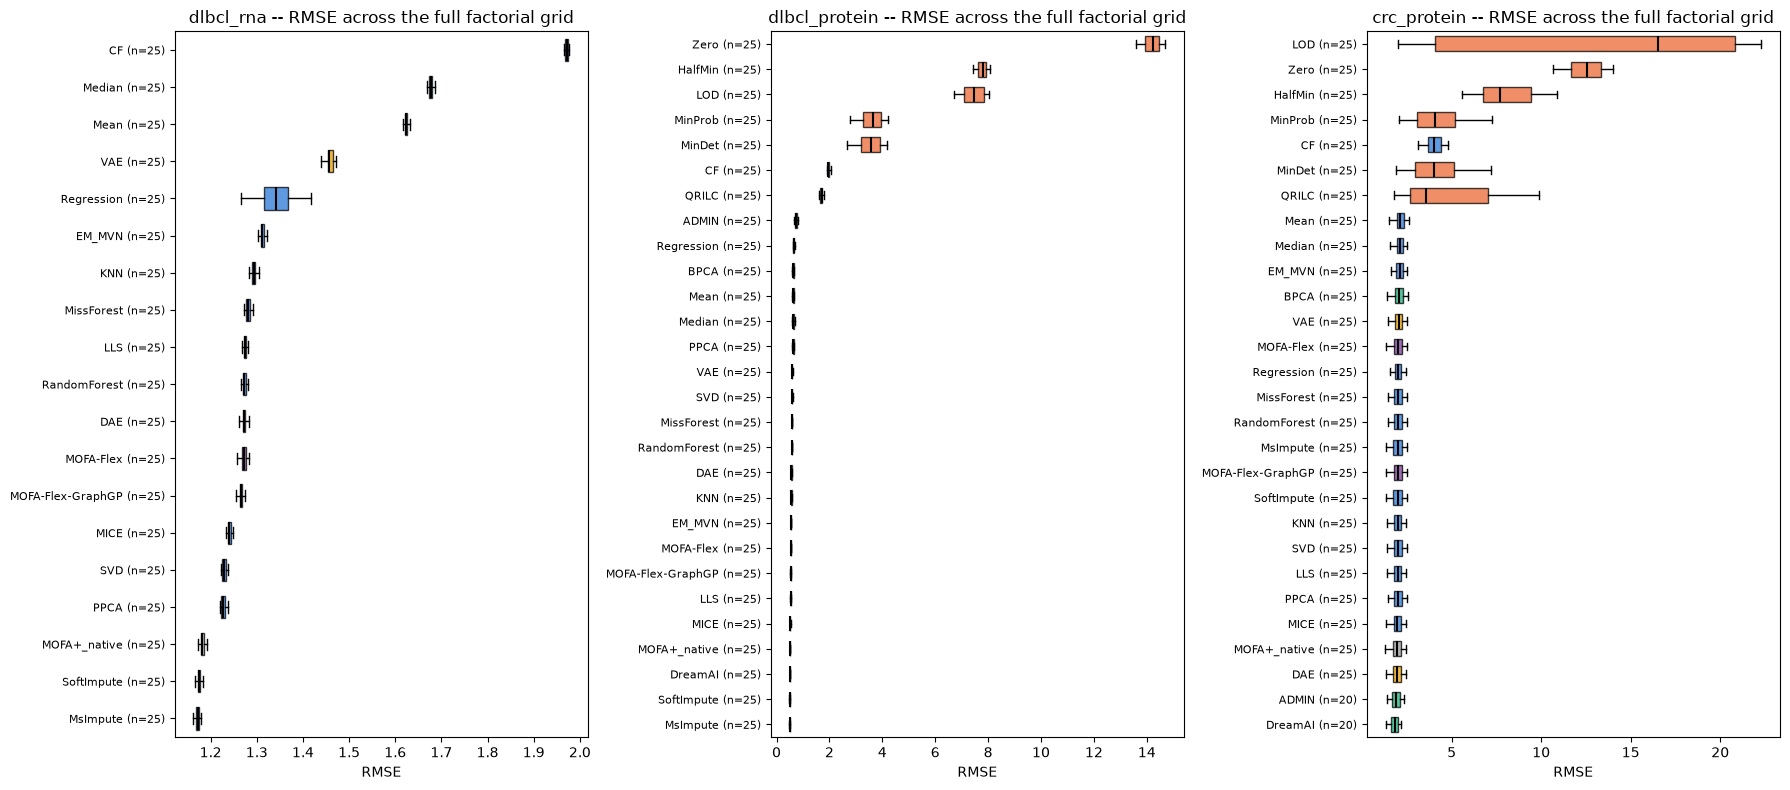

saved fig1_rmse_boxplot.png


In [65]:
# --- Cell 11: Fig 1 - full-grid RMSE boxplot per matrix -------
if HAVE_FULL_GRID:
    fig, axes = plt.subplots(1, len(MATRICES), figsize=(6 * len(MATRICES), 8))
    if len(MATRICES) == 1:
        axes = [axes]
    for ax, matrix_name in zip(axes, MATRICES):
        _boxplot_by_method(ax, all_results, "RMSE", matrix_name, "RMSE across the full factorial grid")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "fig1_rmse_boxplot.png", dpi=150)
    plt.show()
    plt.close(fig)
    print("saved fig1_rmse_boxplot.png")
else:
    print("skipped (no full-grid results yet)")

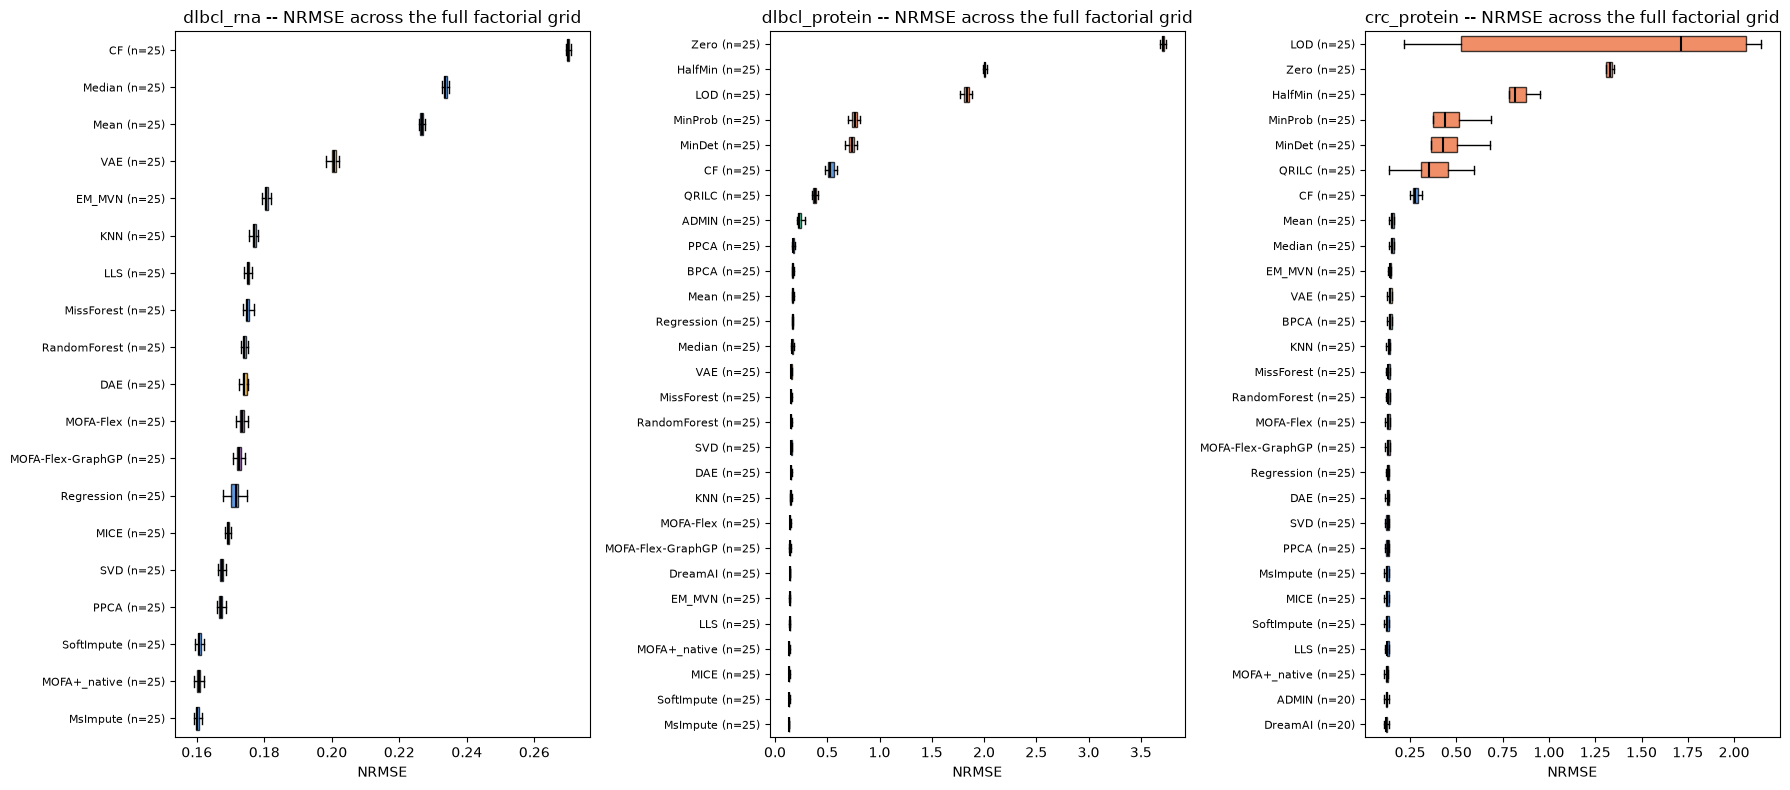

saved fig2_nrmse_boxplot.png


In [66]:
# --- Cell 12: Fig 2 --- full-grid NRMSE boxplot per matrix ------
# NRMSE is the primary cross-feature-scale-fair metric (Ma et al. 2020) -- arguably the
# single most trustworthy full-grid ranking metric we have here.
if HAVE_FULL_GRID:
    fig, axes = plt.subplots(1, len(MATRICES), figsize=(6 * len(MATRICES), 8))
    if len(MATRICES) == 1:
        axes = [axes]
    for ax, matrix_name in zip(axes, MATRICES):
        _boxplot_by_method(ax, all_results, "NRMSE", matrix_name, "NRMSE across the full factorial grid")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "fig2_nrmse_boxplot.png", dpi=150)
    plt.show()
    plt.close(fig)
    print("saved fig2_nrmse_boxplot.png")
else:
    print("skipped (no full-grid results yet)")

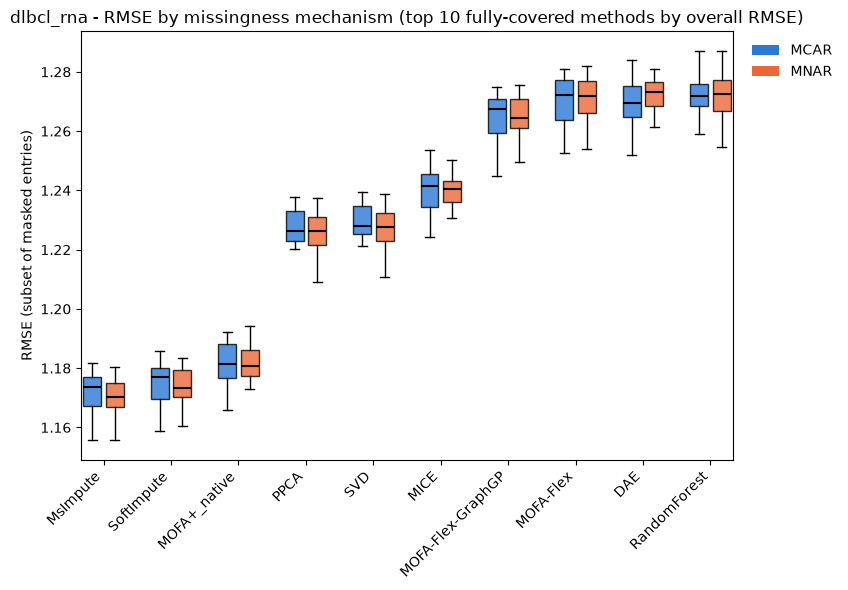

saved fig3_mechanism_split_dlbcl_rna.png


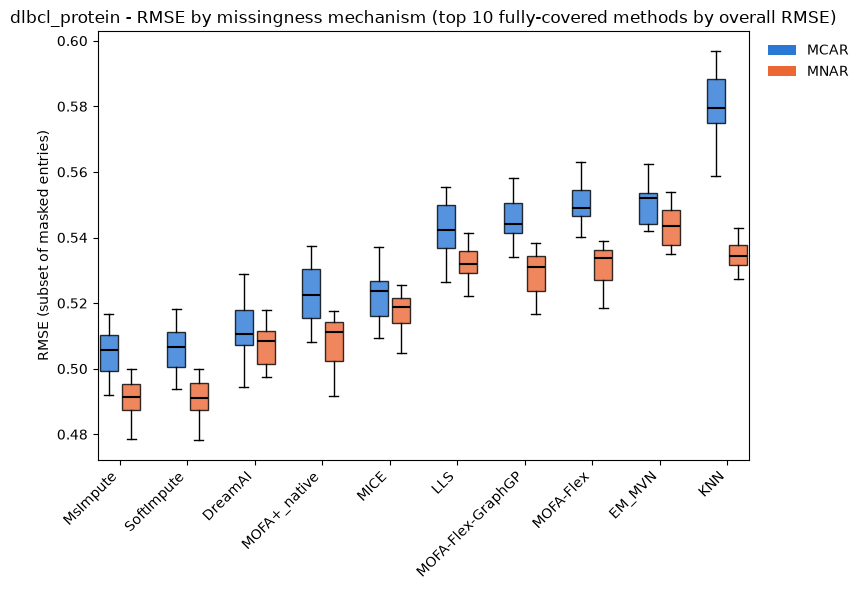

saved fig3_mechanism_split_dlbcl_protein.png


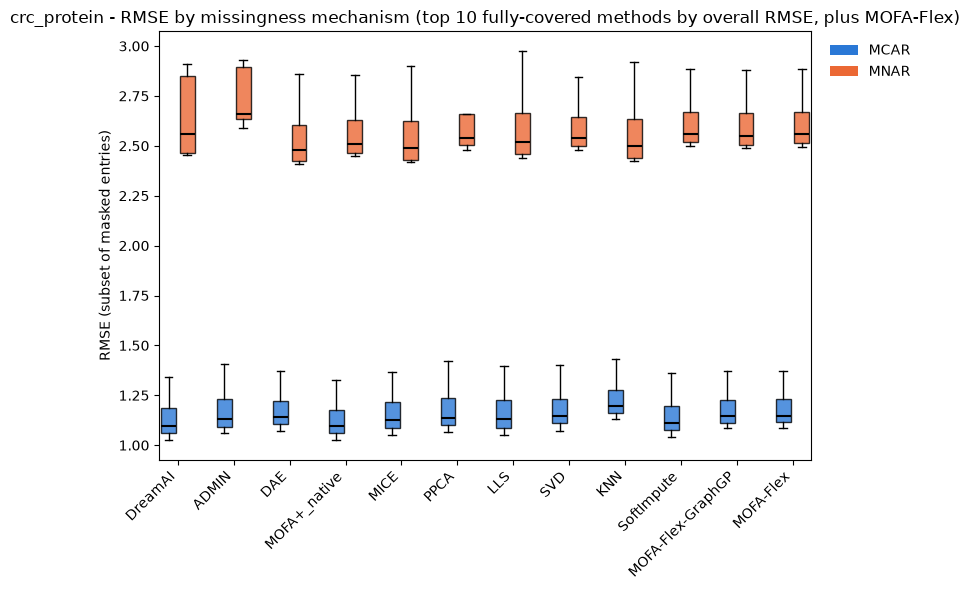

saved fig3_mechanism_split_crc_protein.png


In [67]:
# --- Cell 13: Fig 3 --- MCAR vs MNAR mechanism-split RMSE ------
#  MOFA+ assume MAR/MCAR missingness in how it handle masked entries, so this shows whether these
# 25 methods already degrade under MNAR - which is the baseline MOFA-Flex will need to beat
# *specifically in the MNAR regime* to demonstrate a genuine advantage tied to its
# missing-data handling, not just a general improvement in model fit.
if HAVE_FULL_GRID and {"RMSE_MCAR_subset", "RMSE_MNAR_subset"}.issubset(all_results.columns):
    mech_long = all_results.melt(
        id_vars=["Matrix", "Method"], value_vars=["RMSE_MCAR_subset", "RMSE_MNAR_subset"],
        var_name="Mechanism", value_name="RMSE_subset",
    ).dropna(subset=["RMSE_subset"])
    mech_long["Mechanism"] = mech_long["Mechanism"].str.replace("RMSE_", "").str.replace("_subset", "")

    for matrix_name in MATRICES:
        sub = mech_long[mech_long["Matrix"] == matrix_name]
        if sub.empty:
            continue
        matrix_results = all_results[all_results["Matrix"] == matrix_name]
        covered, under_covered = _fully_covered_methods(matrix_results, matrix_name)
        if under_covered:
            print(f"  {matrix_name}: excluding {len(under_covered)} under-covered method(s) from the "
                  f"top-10 ranking pool (partial/incomplete run - would otherwise compete on a "
                  f"smaller, possibly easier sample than a fully-covered method): " +
                  ", ".join(f"{m} ({n}/{exp})" for m, n, exp in sorted(under_covered)))
        ranked_full = matrix_results.groupby("Method")["RMSE"].median().dropna().sort_values()
        ranked = ranked_full[ranked_full.index.isin(covered)]
        top_methods = list(ranked.index[:10])
        # MOFA+ and MOFA-Flex are always shown here, even if they miss the top-10 cut on
        # raw RMSE (or are themselves under-covered).
        special_here = [m for m in ranked_full.index if m in SPECIAL_METHOD_NAMES and m in covered and m not in top_methods]
        top_methods = top_methods + special_here
        sub = sub[sub["Method"].isin(top_methods)]
        fig, ax = plt.subplots(figsize=(10, 6))
        positions, labels, data, colors = [], [], [], []
        for i, m in enumerate(top_methods):
            for j, mech in enumerate(["MCAR", "MNAR"]):
                vals = sub.loc[(sub["Method"] == m) & (sub["Mechanism"] == mech), "RMSE_subset"].values
                if len(vals) == 0:
                    continue
                positions.append(i * 3 + j)
                data.append(vals)
                colors.append(PALETTE[0] if mech == "MCAR" else PALETTE[1])
            labels.append((i * 3 + 0.5, m))
        bp = ax.boxplot(data, positions=positions, widths=0.8, patch_artist=True, showfliers=False, medianprops=dict(color="black", linewidth=1.5))
        for patch, c in zip(bp["boxes"], colors):
            patch.set_facecolor(c)
            patch.set_alpha(0.8)
        ax.set_xticks([p for p, _ in labels])
        ax.set_xticklabels([m for _, m in labels], rotation=45, ha="right")
        ax.set_ylabel("RMSE (subset of masked entries)")
        present_families = sorted({method_family(m) for m in special_here})
        title_suffix = f", plus {', '.join(present_families)}" if special_here else ""
        ax.set_title(f"{matrix_name} - RMSE by missingness mechanism (top 10 fully-covered methods by overall RMSE{title_suffix})")
        from matplotlib.patches import Patch
        ax.legend(
            handles=[Patch(facecolor=PALETTE[0], label="MCAR"), Patch(facecolor=PALETTE[1], label="MNAR")],
            loc="center left", bbox_to_anchor=(1.02, 0.93), borderaxespad=0, frameon=False,
        )
        fig.tight_layout(rect=[0, 0, 0.85, 1])  # reserve the right ~15% of the figure for the legend
        fig.savefig(FIGURES_DIR / f"fig3_mechanism_split_{matrix_name}.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"saved fig3_mechanism_split_{matrix_name}.png")
else:
    print("skipped (no full-grid results, or mechanism-subset columns absent - "
          "these are only recorded when a scenario actually contains both mechanisms)")


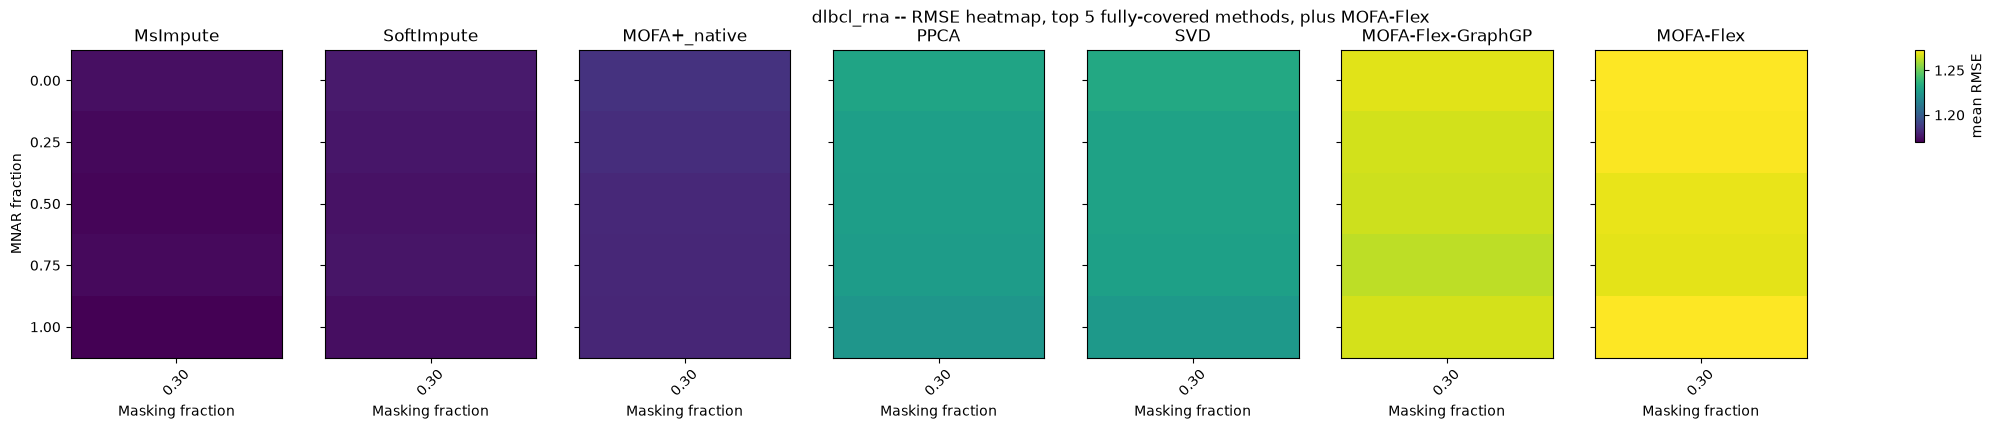

saved fig4_rmse_heatmap_dlbcl_rna.png


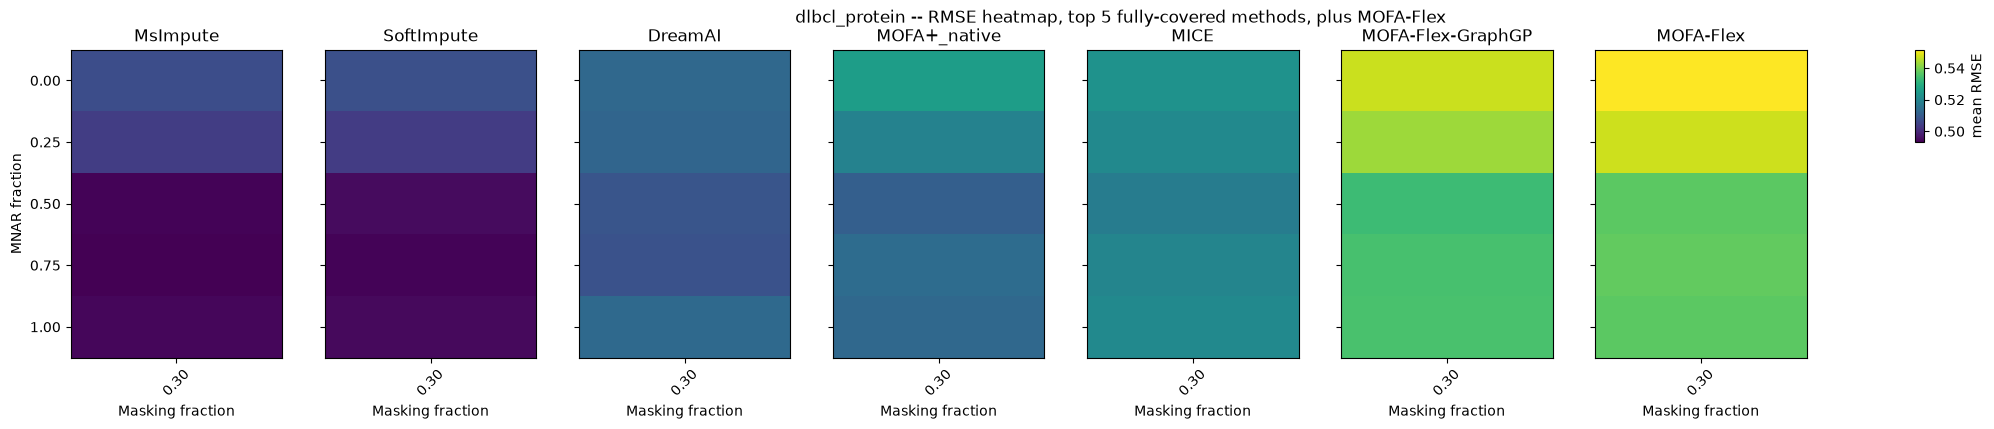

saved fig4_rmse_heatmap_dlbcl_protein.png
  - crc_protein/DreamAI: no result for (MNAR, masking) = [(np.float64(1.0), np.float64(0.3))] - could be a scenario this method's grid never covers by design, or one that just hasn't run yet; check benchmark_checkpoint_crc_protein.csv directly for this method if that distinction matters here.
  - crc_protein/ADMIN: no result for (MNAR, masking) = [(np.float64(1.0), np.float64(0.3))] - could be a scenario this method's grid never covers by design, or one that just hasn't run yet; check benchmark_checkpoint_crc_protein.csv directly for this method if that distinction matters here.


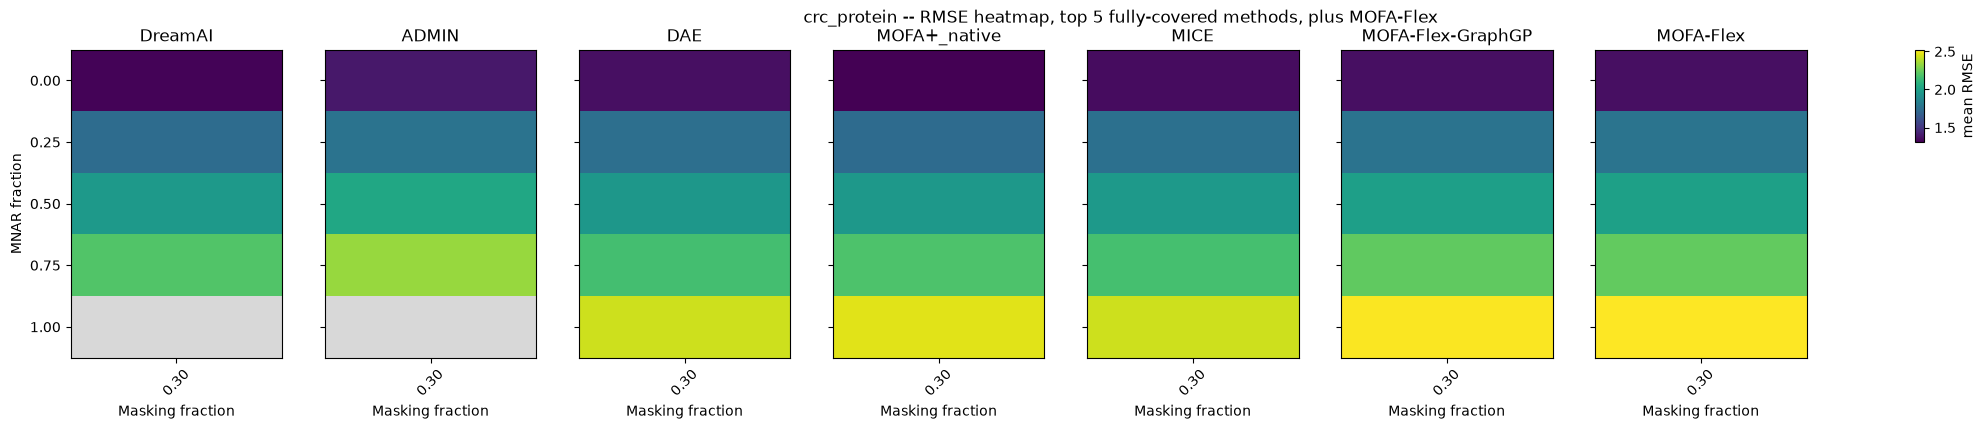

saved fig4_rmse_heatmap_crc_protein.png


In [60]:
# --- Cell 14: Fig 4 --- RMSE heatmap by masking fraction x MNAR fraction ------
# Shown for the top-5 fully-covered methods per matrix (by overall median RMSE), plus
# MOFA+ even when it doesn't make that cut - same reasoning as Fig 3.
if HAVE_FULL_GRID:
    for matrix_name in MATRICES:
        sub = all_results[all_results["Matrix"] == matrix_name]
        if sub.empty:
            continue
        covered, under_covered = _fully_covered_methods(sub, matrix_name)
        if under_covered:
            print(f"  {matrix_name}: excluding {len(under_covered)} under-covered method(s) from the "
                  f"top-5 ranking pool: " +
                  ", ".join(f"{m} ({n}/{exp})" for m, n, exp in sorted(under_covered)))
        ranked_full = sub.groupby("Method")["RMSE"].median().dropna().sort_values()
        ranked = ranked_full[ranked_full.index.isin(covered)]
        top5 = list(ranked.index[:5])
        special_here = [m for m in ranked_full.index if m in SPECIAL_METHOD_NAMES and m in covered and m not in top5]
        methods_to_plot = top5 + special_here

        # Every method's pivot is reindexed to the SAME full (MNAR_Fraction x
        # Masking_Fraction) grid, taken from the union of values actually present for this
        # matrix - rather than letting each method keep whatever narrower index/columns its
        # own pivot_table() happens to produce. Reindexing first means every
        # panel has an identically-shaped grid, so sharey has nothing left to mismatch, and a
        # genuinely-missing cell renders as an explicit gray gap instead of eating a
        # neighboring row's data.
        full_mnar = sorted(sub["MNAR_Fraction"].unique())
        full_masking = sorted(sub["Masking_Fraction"].unique())
        pivots = {
            m: sub[sub["Method"] == m].pivot_table(
                index="MNAR_Fraction", columns="Masking_Fraction", values="RMSE", aggfunc="mean"
            ).reindex(index=full_mnar, columns=full_masking)
            for m in methods_to_plot
        }

        # np.nanmin/np.nanmax over each pivot individually, not the bare min()/max()
        # builtins over p.values.min()/.max() - a pivot that is partially or entirely
        # NaN (a method failing on most/all scenarios used here) makes plain min()/max()
        # comparisons involving NaN order-dependent and unreliable (nan < x and x < nan
        # are both False), this silently produce a physically-impossible colorbar
        # range (e.g. a negative lower bound for an RMSE metric) for the whole row of
        # panels instead of raising an error.
        _finite_pivots = [p.values for p in pivots.values() if not np.isnan(p.values).all()]
        vmin = min(np.nanmin(v) for v in _finite_pivots) if _finite_pivots else 0.0
        vmax = max(np.nanmax(v) for v in _finite_pivots) if _finite_pivots else 1.0
        for _m, _p in pivots.items():
            missing = [(mn, mk) for mn in full_mnar for mk in full_masking if np.isnan(_p.loc[mn, mk])]
            if len(missing) == len(full_mnar) * len(full_masking):
                print(f"  !! {matrix_name}/{_m}: pivot is entirely NaN (method likely failed on "
                      f"every scenario used here) - panel will render blank; check "
                      f"benchmark_checkpoint_{matrix_name}.csv's Error column for this method.")
            elif missing:
                print(f"  - {matrix_name}/{_m}: no result for (MNAR, masking) = {missing} - "
                      f"could be a scenario this method's grid never covers by design, or one "
                      f"that just hasn't run yet; check benchmark_checkpoint_{matrix_name}.csv "
                      f"directly for this method if that distinction matters here.")

        cmap = plt.get_cmap("viridis").copy()
        cmap.set_bad(color="0.85")  # a cell with no recorded RMSE for this method - distinct
                                    # from any real (however low) RMSE value on the same scale
        fig, axes = plt.subplots(1, len(methods_to_plot), figsize=(4 * len(methods_to_plot), 4), sharey=True)
        if len(methods_to_plot) == 1:
            axes = [axes]
        for ax, m in zip(axes, methods_to_plot):
            pivot = pivots[m]
            im = ax.imshow(pivot.values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
            ax.set_xticks(range(len(pivot.columns)))
            ax.set_xticklabels([f"{c:.2f}" for c in pivot.columns], rotation=45)
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels([f"{i:.2f}" for i in pivot.index])
            ax.set_xlabel("Masking fraction")
            ax.set_title(m)
        axes[0].set_ylabel("MNAR fraction")
       
        fig.colorbar(im, ax=axes, label="mean RMSE", shrink=0.3, aspect=10, anchor=(0.0, 1.0))
        present_families = sorted({method_family(m) for m in special_here})
        title_suffix = f", plus {', '.join(present_families)}" if special_here else ""
        fig.suptitle(f"{matrix_name} -- RMSE heatmap, top 5 fully-covered methods{title_suffix}")
        fig.savefig(FIGURES_DIR / f"fig4_rmse_heatmap_{matrix_name}.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"saved fig4_rmse_heatmap_{matrix_name}.png")
else:
    print("skipped (no full-grid results yet)")


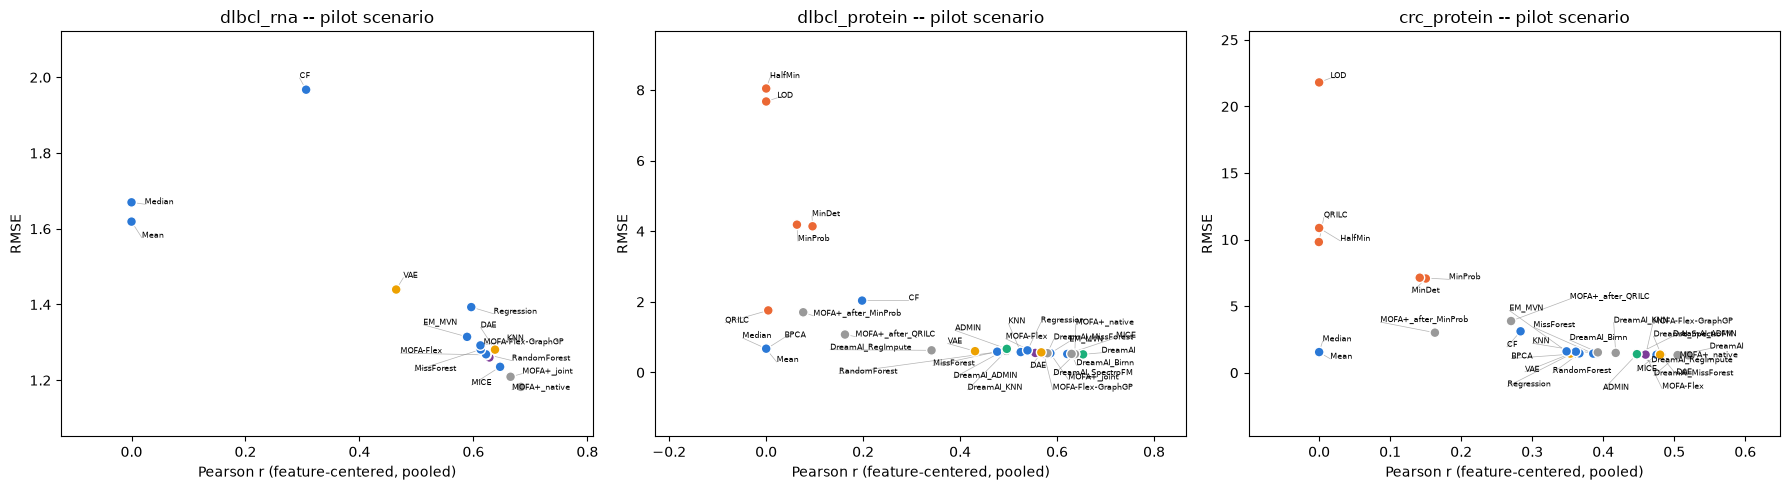

saved fig5_corr_vs_rmse.png


In [61]:
# --- Cell 15: Fig 5 --- pilot-scenario correlation vs RMSE scatter -----
# A sanity/consistency check: methods with a better (higher) feature-centered pooled
# correlation should generally have a lower RMSE. Large deviations from that trend are
# worth a closer look - e.g. a method that tracks relative feature patterns well but is
# badly mis-scaled, or vice versa.
FIG5_COLS = ["RMSE", "Pearson_r_feature_centered_pooled"]
_missing_fig5_cols = [c for c in FIG5_COLS if c not in pilot_summary.columns]
if _missing_fig5_cols:
    print(
        f"Fig 5 skipped - pilot_summary is missing {_missing_fig5_cols}.\n"
        f"pilot_summary columns right now: {list(pilot_summary.columns)}\n"
        "Cell 6 and/or Cell 7 haven't actually run in this kernel session - editing a cell's "
        "code does not retroactively change a variable an earlier run already computed. "
        "Re-run Cell 6, then Cell 7, then this cell, in that order."
    )
else:
    from matplotlib.transforms import Bbox

    def _declutter_scatter_labels(fig, ax, texts, marker_xy_data, pad=2.0, marker_radius_px=9.0,
                                   max_iter=800):
        """Fallback used only when `adjustText` isn't installed - adjusts overlapping
        annotation labels in pixel space to resolve collisions between label bounding
        boxes and each other / the data markers, moving each label's `xytext` offset
        iteratively."""
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        marker_disp = [np.array(ax.transData.transform(xy)) for xy in marker_xy_data]

        for it in range(max_iter):
            bboxes = [t.get_window_extent(renderer=renderer) for t in texts]
            moved_any = False

            for i in range(len(texts)):
                for j in range(i + 1, len(texts)):
                    bi, bj = bboxes[i], bboxes[j]
                    bi_pad = bi.expanded(pad, pad)
                    if not bi_pad.overlaps(bj):
                        continue
                    moved_any = True
                    overlap_mag = max(min(bi_pad.x1, bj.x1) - max(bi_pad.x0, bj.x0),
                                       min(bi_pad.y1, bj.y1) - max(bi_pad.y0, bj.y0))
                    ci = np.array([bi.x0 + bi.width / 2, bi.y0 + bi.height / 2])
                    cj = np.array([bj.x0 + bj.width / 2, bj.y0 + bj.height / 2])
                    direction = ci - cj
                    norm = np.linalg.norm(direction)
                    direction = direction / norm if norm > 1e-6 else \
                        np.array([np.cos(i * 2.399963), np.sin(i * 2.399963)])
                    step = 0.08 * overlap_mag + 0.7
                    for t, sign in ((texts[i], 1), (texts[j], -1)):
                        disp = np.array(t.get_transform().transform(t.get_position()))
                        disp = disp + sign * direction * step
                        t.set_position(t.get_transform().inverted().transform(disp))

            bboxes = [t.get_window_extent(renderer=renderer) for t in texts]
            for i, bi in enumerate(bboxes):
                for mk in marker_disp:
                    mbox = Bbox.from_bounds(mk[0] - marker_radius_px, mk[1] - marker_radius_px,
                                             2 * marker_radius_px, 2 * marker_radius_px)
                    if not bi.overlaps(mbox):
                        continue
                    moved_any = True
                    center = np.array([bi.x0 + bi.width / 2, bi.y0 + bi.height / 2])
                    direction = center - mk
                    norm = np.linalg.norm(direction)
                    direction = direction / norm if norm > 1e-6 else \
                        np.array([np.cos(i * 2.399963), np.sin(i * 2.399963)])
                    disp = np.array(texts[i].get_transform().transform(texts[i].get_position()))
                    disp = disp + direction * 1.4
                    texts[i].set_position(texts[i].get_transform().inverted().transform(disp))

            if it % 30 == 0 or not moved_any:
                fig.canvas.draw()
                renderer = fig.canvas.get_renderer()
            if not moved_any:
                break
        return texts

    def _clamp_labels_to_axes(fig, ax, texts, pad_px=3.0):
        """Nudges any label whose bounding box ended up outside the axes back inside
        it. Neither adjustText nor the fallback decluttering above stops a label from
        being repelled straight past the plot boundary once its marker sits near an
        edge 
        """
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        ax_box = ax.get_window_extent(renderer=renderer)
        for t in texts:
            bbox = t.get_window_extent(renderer=renderer)
            dx = dy = 0.0
            if bbox.x0 < ax_box.x0 + pad_px:
                dx = (ax_box.x0 + pad_px) - bbox.x0
            elif bbox.x1 > ax_box.x1 - pad_px:
                dx = (ax_box.x1 - pad_px) - bbox.x1
            if bbox.y0 < ax_box.y0 + pad_px:
                dy = (ax_box.y0 + pad_px) - bbox.y0
            elif bbox.y1 > ax_box.y1 - pad_px:
                dy = (ax_box.y1 - pad_px) - bbox.y1
            if dx or dy:
                disp = np.array(t.get_transform().transform(t.get_position()))
                disp = disp + [dx, dy]
                t.set_position(t.get_transform().inverted().transform(disp))
        fig.canvas.draw()

    GOLDEN_ANGLE = 137.508 * np.pi / 180

    fig, axes = plt.subplots(1, len(MATRICES), figsize=(6 * len(MATRICES), 5))
    if len(MATRICES) == 1:
        axes = [axes]
    for ax, matrix_name in zip(axes, MATRICES):
        sub = pilot_summary[pilot_summary["Matrix"] == matrix_name].dropna(subset=FIG5_COLS)
        if sub.empty:
            ax.set_visible(False)
            continue
        sub = sub.reset_index(drop=True)
        colors = [FAMILY_COLOR[method_family(m)] for m in sub["Method"]]
        ax.scatter(sub["Pearson_r_feature_centered_pooled"], sub["RMSE"], c=colors, s=50,
                   edgecolor="white", zorder=3)
        ax.set_xlabel("Pearson r (feature-centered, pooled)")
        ax.set_ylabel("RMSE")
        ax.set_title(f"{matrix_name} -- pilot scenario")
        # Extra headroom around the data so labels near an edge point
        # have somewhere to go besides straight off the plot.
        ax.margins(x=0.18, y=0.15)

        # Labels placed with a deterministic golden-angle initial offset,
        # then repelled apart from each other and from the markers so method names
        # stop overlapping into unreadable clutter. 
        fig.canvas.draw()
        texts, marker_xy = [], []
        for idx, row in sub.iterrows():
            x, y = row["Pearson_r_feature_centered_pooled"], row["RMSE"]
            marker_xy.append((x, y))
            angle = idx * GOLDEN_ANGLE
            p0 = np.array(ax.transData.transform((x, y)))
            dx, dy = ax.transData.inverted().transform(p0 + [9 * np.cos(angle), 9 * np.sin(angle)]) - (x, y)
            t = ax.annotate(row["Method"], xy=(x, y), xycoords="data",
                             xytext=(x + dx, y + dy), textcoords="data", fontsize=6, zorder=5)
            texts.append(t)

        try:
            from adjustText import adjust_text
            adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5, alpha=0.6))
            _clamp_labels_to_axes(fig, ax, texts)
        except ImportError:
            _declutter_scatter_labels(fig, ax, texts, marker_xy)
            _clamp_labels_to_axes(fig, ax, texts)
            xr = (sub["Pearson_r_feature_centered_pooled"].max()
                  - sub["Pearson_r_feature_centered_pooled"].min()) or 1.0
            yr = (sub["RMSE"].max() - sub["RMSE"].min()) or 1.0
            for (mx, my), t in zip(marker_xy, texts):
                lx, ly = t.get_position()
                if np.hypot((lx - mx) / xr, (ly - my) / yr) > 0.02:
                    ax.plot([mx, lx], [my, ly], color="gray", linewidth=0.5, alpha=0.6, zorder=1)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "fig5_corr_vs_rmse.png", dpi=150)
    plt.show()
    plt.close(fig)
    print("saved fig5_corr_vs_rmse.png")

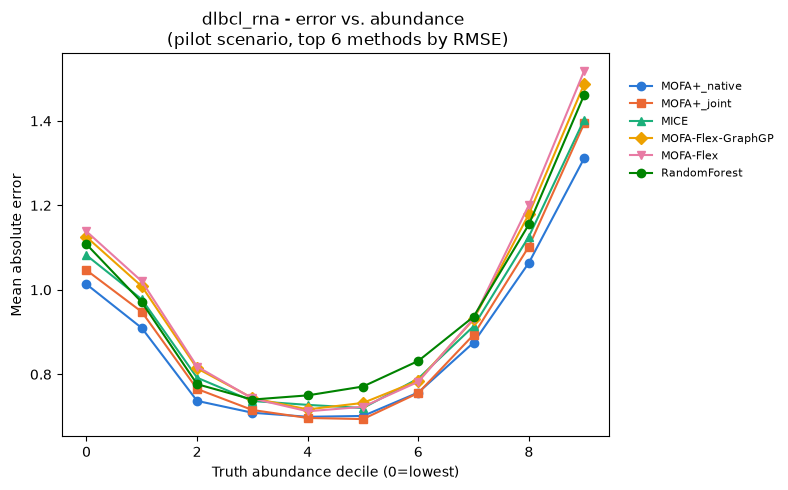

saved fig6_error_vs_abundance_dlbcl_rna.png


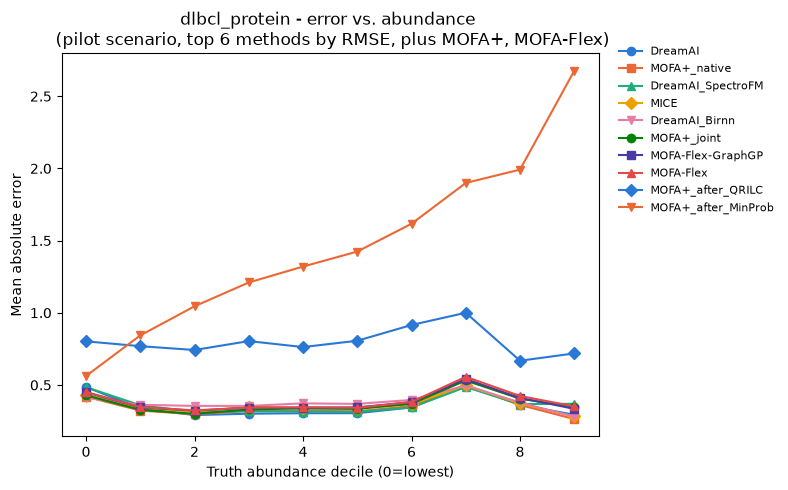

saved fig6_error_vs_abundance_dlbcl_protein.png


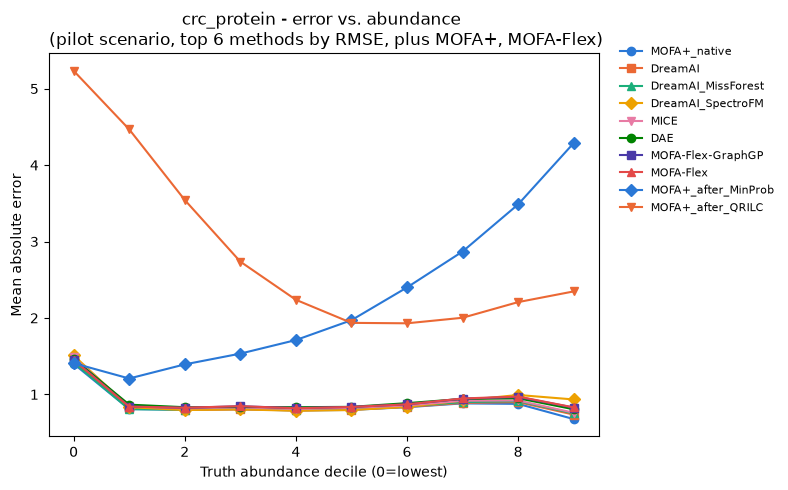

saved fig6_error_vs_abundance_crc_protein.png


In [62]:
# --- Cell 16: Fig 6 --- error vs. truth-abundance decile (pilot scenario) -------
# Reveals whether error concentrates at the low-abundance end, which is directly relevant
# to the MNAR/detection-limit framing: low-abundance values are the ones most likely to be
# MNAR in real MS proteomics, even though this pilot scenario itself is pure MCAR by
# design. So this figure shows whether error is abundance-dependent even under MCAR - a
# separate, still-useful signal alongside the MCAR/MNAR mechanism-split figure above.
N_DECILES = 10
# Up to ~10 methods can appear in one panel (top 6 + MOFA+/MOFA-Flex extras), more than
# PALETTE's 4 colors, so color alone repeats. Cycle color (8 CVD-safe hues) and marker
# shape (5 shapes) on separate, coprime-length cycles so no two of the first 40 series
# share both color and marker.
FIG6_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
FIG6_MARKERS = ["o", "s", "^", "D", "v"]
for matrix_name, X_truth in MATRICES.items():
    Y_masked, mask, mechanism = build_masked_scenario(PILOT_ROW, X_truth)
    matrix_summary = pilot_summary[pilot_summary["Matrix"] == matrix_name].dropna(subset=["RMSE"])
    top_methods = matrix_summary.nsmallest(6, "RMSE")["Method"].tolist()
    # MOFA+ and MOFA-Flex are shown here too, even when they fall outside the top 6 -
    # same reasoning as Figs 3 and 4.
    special_here = [
        m for m in matrix_summary.sort_values("RMSE")["Method"] if m in SPECIAL_METHOD_NAMES and m not in top_methods
    ]
    top_methods = top_methods + special_here

    fig, ax = plt.subplots(figsize=(8, 5))
    truth_vals = X_truth.values[mask.values]
    deciles = pd.qcut(truth_vals, N_DECILES, labels=False, duplicates="drop")
    for i, method_name in enumerate(top_methods):
        matrix_path = PILOT_MATRICES_DIR / f"pilot_{matrix_name}_imputed_{method_name}.csv"
        if not matrix_path.exists():
            continue
        X_hat = pd.read_csv(matrix_path, index_col=0).reindex(index=X_truth.index, columns=X_truth.columns)
        pred_vals = X_hat.values[mask.values]
        abs_err = np.abs(truth_vals - pred_vals)
        valid = np.isfinite(abs_err)
        mean_err_by_decile = pd.Series(abs_err[valid]).groupby(deciles[valid]).mean()
        ax.plot(mean_err_by_decile.index, mean_err_by_decile.values,
                marker=FIG6_MARKERS[i % len(FIG6_MARKERS)],
                label=method_name, color=FIG6_COLORS[i % len(FIG6_COLORS)])
    ax.set_xlabel("Truth abundance decile (0=lowest)")
    ax.set_ylabel("Mean absolute error")
    present_families = sorted({method_family(m) for m in special_here})
    title_suffix = f", plus {', '.join(present_families)}" if special_here else ""
    ax.set_title(f"{matrix_name} - error vs. abundance \n (pilot scenario, top 6 methods by RMSE{title_suffix})")
    ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.80), frameon=False)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"fig6_error_vs_abundance_{matrix_name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"saved fig6_error_vs_abundance_{matrix_name}.png")

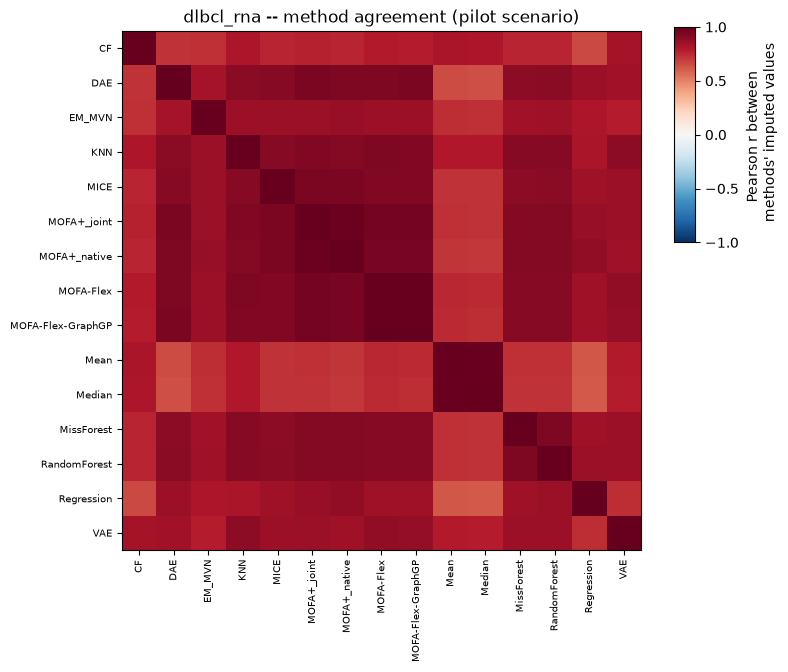

saved fig7_method_agreement_dlbcl_rna.png


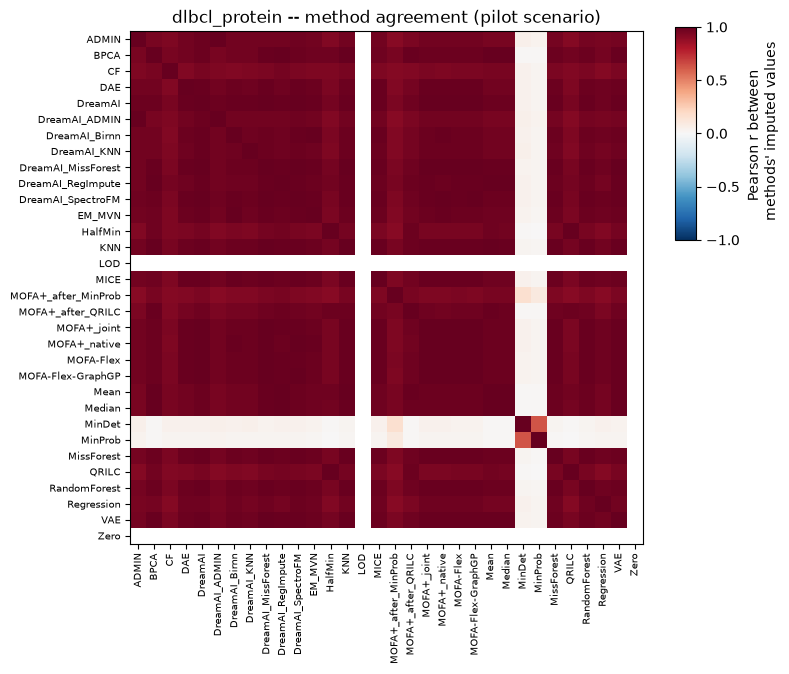

saved fig7_method_agreement_dlbcl_protein.png


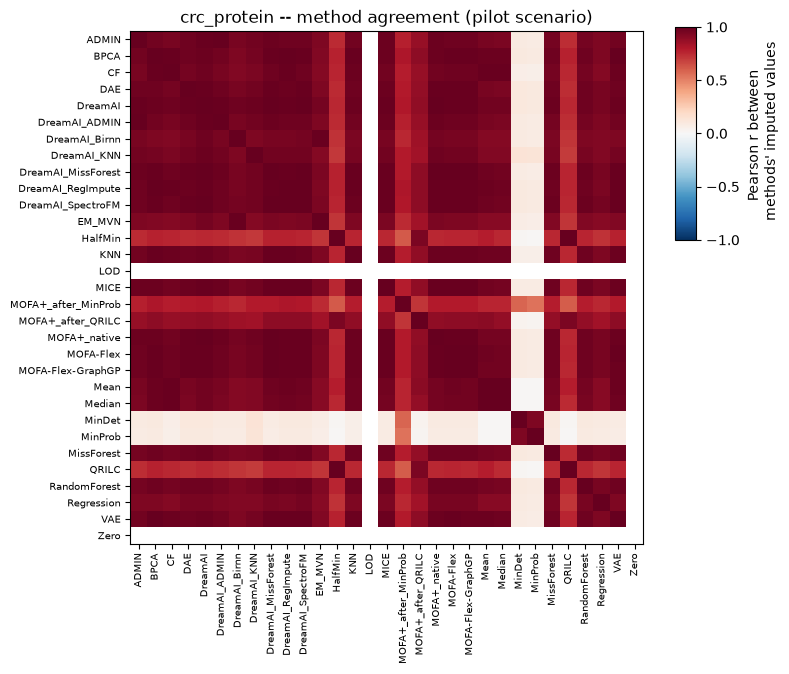

saved fig7_method_agreement_crc_protein.png


In [63]:
# --- Cell 17: Fig 7 ----- pairwise method-agreement heatmap (pilot scenario) --------
# Looks at how similar different methods' imputed values are to each other 
# on the masked entries - this reveals which methods behave like near-duplicates versus
# genuinely different approaches.

FIG7_BASE_SIZE = 2.0       # inches of fixed padding (title, tick labels, colorbar margin)
FIG7_PER_METHOD = 0.4      # additional inches per method, in both width and height
FIG7_MIN_SIZE = 4.0        # inches - floor, regardless of how few methods there are
FIG7_MAX_SIZE = 8.0        # inches - ceiling, regardless of how many methods there are

for matrix_name, X_truth in MATRICES.items():
    Y_masked, mask, mechanism = build_masked_scenario(PILOT_ROW, X_truth)
    methods_here = sorted(
        m for m in pilot_summary.loc[pilot_summary["Matrix"] == matrix_name, "Method"]
        if (PILOT_MATRICES_DIR / f"pilot_{matrix_name}_imputed_{m}.csv").exists()
    )
    if len(methods_here) < 2:
        continue
    vecs = {}
    for m in methods_here:
        X_hat = pd.read_csv(PILOT_MATRICES_DIR / f"pilot_{matrix_name}_imputed_{m}.csv", index_col=0)
        X_hat = X_hat.reindex(index=X_truth.index, columns=X_truth.columns)
        vecs[m] = X_hat.values[mask.values]
    agreement = pd.DataFrame(vecs).corr(method="pearson")
    fig_size = min(max(FIG7_BASE_SIZE + FIG7_PER_METHOD * len(methods_here), FIG7_MIN_SIZE), FIG7_MAX_SIZE)
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    im = ax.imshow(agreement.values, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(methods_here)))
    ax.set_xticklabels(methods_here, rotation=90, fontsize=7)
    ax.set_yticks(range(len(methods_here)))
    ax.set_yticklabels(methods_here, fontsize=7)
    # Short and top-aligned rather than the default full-height colorbar
    fig.colorbar(im, ax=ax, shrink=0.3, aspect=10, anchor=(0.0, 0.81),
                 label="Pearson r between \n methods' imputed values")
    ax.set_title(f"{matrix_name} -- method agreement (pilot scenario)")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"fig7_method_agreement_{matrix_name}.png", dpi=150)
    plt.show()
    plt.close(fig)
    print(f"saved fig7_method_agreement_{matrix_name}.png")